In [2]:
import math
from pathlib import Path

import pandas as pd

try:
    import rasterio
    from rasterio.warp import transform as warp_transform
except Exception as e:
    raise SystemExit(
        "This script requires rasterio (and its dependencies). "
        "Install it and retry. Original error: " + str(e)
    )

ROOT = Path("/data2/yuyao/methane_emission")
CSV_PATH = ROOT / "preprocess_dataset_s2/CM_S2_L2A.csv"
DATA_DIR = ROOT / "carbonmapper_data_l89_l2sp_90360"

COL_MINUS90 = "s2_pre_path(-90)"
COL_MINUS360 = "s2_pre_pre_path (-360)"
EXPECTED_SIZE = (512, 512)  # (width, height)

def pick_path(plume_id: str, token: str):
    d = DATA_DIR / plume_id
    if not d.is_dir():
        return None
    matches = sorted(d.glob(f"*{token}*"))
    if not matches:
        return None
    # store relative path (consistent with existing CSV patterns)
    return str(matches[0].relative_to(ROOT))

def haversine_m(lat1, lon1, lat2, lon2):
    r = 6371000.0
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dl = math.radians(lon2 - lon1)
    a = math.sin(dphi / 2) ** 2 + math.cos(phi1) * math.cos(phi2) * math.sin(dl / 2) ** 2
    return 2 * r * math.asin(math.sqrt(a))

def image_center_latlon(ds):
    # center pixel in raster coordinates
    cx = ds.width / 2.0
    cy = ds.height / 2.0
    x, y = ds.transform * (cx, cy)

    if ds.crs is None:
        return None

    crs_str = ds.crs.to_string()
    if crs_str.upper() in ("EPSG:4326", "WGS84"):
        return (y, x)

    lon, lat = warp_transform(ds.crs, "EPSG:4326", [x], [y])
    return (lat[0], lon[0])

df = pd.read_csv(CSV_PATH)

# Add / overwrite columns
df[COL_MINUS90] = df["plume_id"].map(lambda pid: pick_path(pid, "minus90"))
df[COL_MINUS360] = df["plume_id"].map(lambda pid: pick_path(pid, "minus360"))

df.to_csv(CSV_PATH, index=False)
print(f"Updated CSV written to: {CSV_PATH}")

size_issues = []
center_issues = []
missing_files = []

for i, row in df.iterrows():
    lat = row.get("plume_latitude")
    lon = row.get("plume_longitude")

    for col in (COL_MINUS90, COL_MINUS360):
        rel = row.get(col)
        if pd.isna(rel) or not rel:
            continue

        fp = ROOT / rel
        if not fp.exists():
            missing_files.append((row["plume_id"], col, str(fp)))
            continue

        with rasterio.open(fp) as ds:
            size = (ds.width, ds.height)
            if size != EXPECTED_SIZE:
                size_issues.append((row["plume_id"], col, size, str(fp)))

            if pd.isna(lat) or pd.isna(lon):
                continue

            center = image_center_latlon(ds)
            if center is None:
                continue

            center_lat, center_lon = center
            dist_m = haversine_m(lat, lon, center_lat, center_lon)
            center_issues.append((dist_m, row["plume_id"], col, center_lat, center_lon, lat, lon, str(fp)))

print("\n=== Size Check ===")
if size_issues:
    print(f"Mismatches (expected {EXPECTED_SIZE}): {len(size_issues)}")
    for item in size_issues[:20]:
        print(item)
else:
    print("All checked images match expected size.")

print("\n=== Center Alignment Check ===")
if center_issues:
    # sort by distance descending and report top 20
    center_issues.sort(reverse=True, key=lambda x: x[0])
    print("Top 20 largest center distances (meters):")
    for item in center_issues[:20]:
        dist_m, plume_id, col, c_lat, c_lon, p_lat, p_lon, fp = item
        print(f"{plume_id} {col} dist={dist_m:.2f}m center=({c_lat:.6f},{c_lon:.6f}) plume=({p_lat:.6f},{p_lon:.6f}) file={fp}")
else:
    print("No center checks performed (missing CRS or plume lat/lon).")

print("\n=== Missing Files ===")
if missing_files:
    for item in missing_files[:20]:
        print(item)
else:
    print("No missing files detected.")


Updated CSV written to: /data2/yuyao/methane_emission/preprocess_dataset_s2/CM_S2_L2A.csv


/home/yuyao/miniconda3/envs/data/lib/python3.11/site-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)



=== Size Check ===
All checked images match expected size.

=== Center Alignment Check ===
No center checks performed (missing CRS or plume lat/lon).

=== Missing Files ===
No missing files detected.


In [8]:
import math
from pathlib import Path

import pandas as pd

try:
    import rasterio
    from rasterio.warp import transform as warp_transform
except Exception as e:
    raise SystemExit(
        "This script requires rasterio. Install it and retry. "
        "Original error: " + str(e)
    )

ROOT = Path("/data2/yuyao/methane_emission")
CSV_PATH = ROOT / "preprocess_dataset_s2/CM_S2_L2A.csv"
DATA_DIR = ROOT / "carbonmapper_data_s2_l2a_gee_download"

COL_MINUS90 = "s2_pre_path(-90)"
COL_MINUS360 = "s2_pre_pre_path (-360)"
EXPECTED_SIZE = (512, 512)  # (width, height)

# 映射：列名 -> 文件后缀（不含扩展名）
MAP = {
    COL_MINUS90: "reference_month",
    COL_MINUS360: "reference_year",
}

def pick_path(plume_id: str, suffix: str):
    # flat files like: {plume_id}_{suffix}.tif
    fp = DATA_DIR / f"{plume_id}_{suffix}.tif"
    if fp.exists():
        return str(fp.relative_to(ROOT))
    return None

def haversine_m(lat1, lon1, lat2, lon2):
    r = 6371000.0
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dl = math.radians(lon2 - lon1)
    a = math.sin(dphi / 2) ** 2 + math.cos(phi1) * math.cos(phi2) * math.sin(dl / 2) ** 2
    return 2 * r * math.asin(math.sqrt(a))

def image_center_latlon(ds):
    cx = ds.width / 2.0
    cy = ds.height / 2.0
    x, y = ds.transform * (cx, cy)

    if ds.crs is None:
        return None

    crs_str = ds.crs.to_string()
    if crs_str.upper() in ("EPSG:4326", "WGS84"):
        return (y, x)

    lon, lat = warp_transform(ds.crs, "EPSG:4326", [x], [y])
    return (lat[0], lon[0])

df = pd.read_csv(CSV_PATH)

# 填充两列
for col, suffix in MAP.items():
    df[col] = df["plume_id"].map(lambda pid: pick_path(pid, suffix))

OUT_CSV = "/data2/yuyao/methane_emission/preprocess_dataset_s2/CM_S2_L2A_gee90360.csv"
df.to_csv(OUT_CSV, index=False)
print(f"Updated CSV written to: {OUT_CSV}")

size_issues = []
center_issues = []
missing_files = []

for _, row in df.iterrows():
    lat = row.get("plume_latitude")
    lon = row.get("plume_longitude")

    for col in (COL_MINUS90, COL_MINUS360):
        rel = row.get(col)
        if pd.isna(rel) or not rel:
            continue

        fp = ROOT / rel
        if not fp.exists():
            missing_files.append((row["plume_id"], col, str(fp)))
            continue

        with rasterio.open(fp) as ds:
            size = (ds.width, ds.height)
            if size != EXPECTED_SIZE:
                size_issues.append((row["plume_id"], col, size, str(fp)))

            if pd.isna(lat) or pd.isna(lon):
                continue

            center = image_center_latlon(ds)
            if center is None:
                continue

            center_lat, center_lon = center
            dist_m = haversine_m(lat, lon, center_lat, center_lon)
            center_issues.append((dist_m, row["plume_id"], col, center_lat, center_lon, lat, lon, str(fp)))

print("\n=== Size Check ===")
if size_issues:
    print(f"Mismatches (expected {EXPECTED_SIZE}): {len(size_issues)}")
    for item in size_issues[:20]:
        print(item)
else:
    print("All checked images match expected size.")

print("\n=== Center Alignment Check ===")
if center_issues:
    center_issues.sort(reverse=True, key=lambda x: x[0])
    print("Top 20 largest center distances (meters):")
    for item in center_issues[:20]:
        dist_m, plume_id, col, c_lat, c_lon, p_lat, p_lon, fp = item
        print(f"{plume_id} {col} dist={dist_m:.2f}m center=({c_lat:.6f},{c_lon:.6f}) plume=({p_lat:.6f},{p_lon:.6f}) file={fp}")
else:
    print("No center checks performed (missing CRS or plume lat/lon).")

print("\n=== Missing Files ===")
if missing_files:
    for item in missing_files[:20]:
        print(item)
else:
    print("No missing files detected.")


Updated CSV written to: /data2/yuyao/methane_emission/preprocess_dataset_s2/CM_S2_L2A_gee90360.csv

=== Size Check ===
Mismatches (expected (512, 512)): 8676
('GAO20191020t151740p0000-A', 's2_pre_path(-90)', (596, 514), '/data2/yuyao/methane_emission/carbonmapper_data_s2_l2a_gee_download/GAO20191020t151740p0000-A_reference_month.tif')
('GAO20191020t151740p0000-A', 's2_pre_pre_path (-360)', (596, 514), '/data2/yuyao/methane_emission/carbonmapper_data_s2_l2a_gee_download/GAO20191020t151740p0000-A_reference_year.tif')
('GAO20191020t153619p0000-A', 's2_pre_path(-90)', (595, 514), '/data2/yuyao/methane_emission/carbonmapper_data_s2_l2a_gee_download/GAO20191020t153619p0000-A_reference_month.tif')
('GAO20191020t153619p0000-A', 's2_pre_pre_path (-360)', (595, 514), '/data2/yuyao/methane_emission/carbonmapper_data_s2_l2a_gee_download/GAO20191020t153619p0000-A_reference_year.tif')
('GAO20191020t153619p0000-B', 's2_pre_path(-90)', (596, 514), '/data2/yuyao/methane_emission/carbonmapper_data_s2_l2

In [9]:
df=pd.read_csv("/data2/yuyao/methane_emission/preprocess_dataset_s2/CM_S2_L2A_gee90360.csv")
df.dropna(subset=['s2_pre_path(-90)', 's2_pre_pre_path (-360)'], how='any', inplace=True)
# df.to_csv("/data2/yuyao/methane_emission/preprocess_dataset_s2/CM_S2_L2A_origin.csv",index=False)
print(len(df))

4338


In [3]:
import os
import pandas as pd

csv_path = "/data2/yuyao/methane_emission/carbon_mapper_data/csvs/raw_s2_90360_cleaned.csv"
s2_root = "/data2/yuyao/methane_emission/carbonmapper_data_s2_l2a_complement_by_gee"
plume_col = "plume_id"  # 如需修改列名就在这里改

# 读取原始CSV
df = pd.read_csv(csv_path)

# 构建 plume_id -> s2_path 映射（匹配任意文件，优先取第一个）
plume_to_path = {}
for root, _, files in os.walk(s2_root):
    for fname in files:
        # 根据文件名包含 plume_id 的规则进行匹配
        # 假设文件名里包含 plume_id 的字符串表示
        for plume_id in df[plume_col].astype(str).unique():
            if plume_id in fname:
                plume_to_path[plume_id] = os.path.join(root, fname)

# 更新 s2_path 列（未匹配到的保留原值）
df["s2_path"] = df[plume_col].astype(str).map(plume_to_path).fillna(df["s2_path"])

# 覆盖写回
df.to_csv(csv_path, index=False)

In [10]:
import rasterio

path = "../carbonmapper_data_s2_l2a_gee_download/GAO20191020t151740p0000-A_reference_month.tif"

with rasterio.open(path) as ds:
    # rasterio 的维度：count=波段数, height=行, width=列
    print("bands(count):", ds.count)
    print("height, width:", ds.height, ds.width)
    print("dtype:", ds.dtypes[0])
    # 方便你对齐到数组形状（C,H,W）
    print("CHW shape:", (ds.count, ds.height, ds.width))
    
path = "carbon_mapper_data/CM_S2_L2A/GAO20191020t151740p0000-A/s2.tif"
# path = "/data2/yuyao/methane_emission/carbon_mapper_data/CM_S2_L2A/ang20170926t210253-D/s2.tif"
with rasterio.open(path) as ds:
    # rasterio 的维度：count=波段数, height=行, width=列
    print("bands(count):", ds.count)
    print("height, width:", ds.height, ds.width)
    print("dtype:", ds.dtypes[0])
    # 方便你对齐到数组形状（C,H,W）
    print("CHW shape:", (ds.count, ds.height, ds.width))

bands(count): 12
height, width: 514 596
dtype: uint16
CHW shape: (12, 514, 596)


RasterioIOError: carbon_mapper_data/CM_S2_L2A/GAO20191020t151740p0000-A/s2.tif: No such file or directory

In [11]:
from pathlib import Path
import pandas as pd

CSV_IN = "/data2/yuyao/methane_emission/preprocess_dataset_s2/CM_S2_L2A_gee90360.csv"
CSV_OUT = CSV_IN  # 原地覆盖；想保留原文件就改成新路径
PREFIX = Path("/data2/yuyao/methane_emission")

# 需要处理的列名（按需增删）
COLS = [
    "S2_path",
    "s2_pre_path(-90)",
    "s2_pre_pre_path (-360)",
]

df = pd.read_csv(CSV_IN)

def add_prefix(p):
    if pd.isna(p) or not str(p).strip():
        return p
    p = Path(str(p))
    # 已经是绝对路径就不改
    if p.is_absolute():
        return str(p)
    return str(PREFIX / p)

for c in COLS:
    if c in df.columns:
        df[c] = df[c].map(add_prefix)

df.to_csv(CSV_OUT, index=False)
print("done:", CSV_OUT)


done: /data2/yuyao/methane_emission/preprocess_dataset_s2/CM_S2_L2A_gee90360.csv


In [ ]:
# 1 按照中心进行切割512x512的patch
import os
import shutil
import numpy as np
import pandas as pd
import rasterio
from rasterio.windows import Window
import tifffile as tiff
from tqdm import tqdm

# =========================
# Config
# =========================
csv_in = "/data2/yuyao/methane_emission/preprocess_dataset_s2/CM_S2_L2A_gee90360.csv"

out_base_dir = "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/plume_raw_s2_gee90360_512"
os.makedirs(out_base_dir, exist_ok=True)

csv_out = os.path.join(out_base_dir, "raw_s2_gee90360_512.csv")

patch_size = 512
min_keep_ratio = 0.8
pad_if_smaller = True

band_index_0based = 11     # 第12波段
zero_thresh = 0.2

# CSV field candidates
LAT_CANDIDATES = ["plume_latitude", "latitude", "lat", "center_lat"]
LON_CANDIDATES = ["plume_longitude", "longitude", "lon", "center_lon"]
ID_CANDIDATES  = ["sample_id", "id", "plume_id"]

# output filenames
OUT_S2_STD   = "s2_std_512.tif"
OUT_90_STD   = "s2_90_std_512.tif"
OUT_360_STD  = "s2_360_std_512.tif"

# =========================
# Helpers
# =========================
def pick_first_existing_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def safe_mkdir(p):
    os.makedirs(p, exist_ok=True)

def zero_ratio_band12_bhw(arr_bhw, band_index_0based=11):
    if arr_bhw is None or arr_bhw.ndim != 3:
        return None
    if band_index_0based >= arr_bhw.shape[0]:
        return None
    band = arr_bhw[band_index_0based]
    return float((band == 0).sum()) / float(band.size)

def crop_patch_from_latlon(src, center_lat, center_lon, patch_size=512):
    """Return patch(BHW), start_col_row, read_width, read_height."""
    center_row, center_col = src.index(center_lon, center_lat)
    half = patch_size // 2
    start_col = center_col - half
    start_row = center_row - half

    read_start_col = max(start_col, 0)
    read_start_row = max(start_row, 0)
    read_end_col = min(start_col + patch_size, src.width)
    read_end_row = min(start_row + patch_size, src.height)

    read_width = read_end_col - read_start_col
    read_height = read_end_row - read_start_row
    if read_width <= 0 or read_height <= 0:
        return None, None, 0, 0

    window = Window(read_start_col, read_start_row, read_width, read_height)
    patch = src.read(window=window)  # (bands, read_height, read_width)

    if read_width != patch_size or read_height != patch_size:
        if not pad_if_smaller:
            return None, None, read_width, read_height
        padded = np.zeros((src.count, patch_size, patch_size), dtype=patch.dtype)
        dst_x0 = max(0, -start_col)
        dst_y0 = max(0, -start_row)
        padded[:, dst_y0:dst_y0 + read_height, dst_x0:dst_x0 + read_width] = patch
        patch = padded

    return patch, (start_col, start_row), read_width, read_height

def save_patch_geotiff(patch_bhw, out_path, src, start_col_row, patch_size=512):
    """Write patch as standard GeoTIFF bands-first, keeping CRS/transform if available."""
    start_col, start_row = start_col_row
    win = Window(start_col, start_row, patch_size, patch_size)
    transform = src.window_transform(win)

    meta = src.meta.copy()
    meta.update({
        "height": patch_size,
        "width": patch_size,
        "count": patch_bhw.shape[0],
        "transform": transform,
    })
    with rasterio.open(out_path, "w", **meta) as dst:
        dst.write(patch_bhw)

def standardize_to_bhw(src_path):
    """
    Read with tifffile, return BHW array for consistent band order.
    """
    arr = tiff.imread(src_path)
    if arr.ndim != 3:
        raise ValueError(f"Unexpected ndim: {arr.ndim}, shape={arr.shape}")

    if arr.shape[0] in (12, 13):
        return arr
    if arr.shape[-1] in (12, 13):
        return np.transpose(arr, (2, 0, 1))
    raise ValueError(f"Can't infer bands for s2: shape={arr.shape}")

def crop_and_standardize(src_path, center_lat, center_lon, out_path):
    """
    crop by lat/lon -> standard BHW GeoTIFF
    """
    # 1) read raw pixels with tifffile (保证能读)
    bhw = standardize_to_bhw(src_path)
    bands, H, W = bhw.shape

    # 2) use rasterio for georef + windowing
    with rasterio.open(src_path) as src:
        # read window by lat/lon (based on src georef)
        patch, start, rw, rh = crop_patch_from_latlon(src, center_lat, center_lon, patch_size)
        if patch is None or (rw < patch_size * min_keep_ratio or rh < patch_size * min_keep_ratio):
            return None

        # patch 是 rasterio 读的，如果 band order 与 bhw 不一致，则强制用 bhw 重裁
        # 统一用 bhw 再裁一遍，确保输出是 BHW
        # 计算与 start 对应的窗口
        start_col, start_row = start
        read_start_col = max(start_col, 0)
        read_start_row = max(start_row, 0)
        read_end_col = min(start_col + patch_size, W)
        read_end_row = min(start_row + patch_size, H)

        read_width = read_end_col - read_start_col
        read_height = read_end_row - read_start_row

        if read_width <= 0 or read_height <= 0:
            return None

        bhw_patch = bhw[:, read_start_row:read_end_row, read_start_col:read_end_col]
        if read_width != patch_size or read_height != patch_size:
            if not pad_if_smaller:
                return None
            padded = np.zeros((bands, patch_size, patch_size), dtype=bhw_patch.dtype)
            dst_x0 = max(0, -start_col)
            dst_y0 = max(0, -start_row)
            padded[:, dst_y0:dst_y0 + read_height, dst_x0:dst_x0 + read_width] = bhw_patch
            bhw_patch = padded

        save_patch_geotiff(bhw_patch, out_path, src, start, patch_size)
        return bhw_patch

# =========================
# Main
# =========================
df = pd.read_csv(csv_in)

lat_col = pick_first_existing_col(df, LAT_CANDIDATES)
lon_col = pick_first_existing_col(df, LON_CANDIDATES)
id_col  = pick_first_existing_col(df, ID_CANDIDATES)

if lat_col is None or lon_col is None:
    raise ValueError(f"CSV 缺少经纬度列：lat in {LAT_CANDIDATES}, lon in {LON_CANDIDATES}")
if id_col is None:
    id_col = "__row_index__"
    df[id_col] = np.arange(len(df))

# new path columns
df["s2_path_std"] = None
df["s2_90_path_std"] = None
df["s2_360_path_std"] = None

stats = {
    "s2_std": {"valid": 0, "zero_gt": 0},
    "s2_90_std": {"valid": 0, "zero_gt": 0},
    "s2_360_std": {"valid": 0, "zero_gt": 0},
}
skipped = 0

for idx, row in tqdm(df.iterrows(), total=len(df), desc="Build fixed dataset"):
    sample_id = str(row[id_col])
    center_lat = row[lat_col]
    center_lon = row[lon_col]
    if pd.isna(center_lat) or pd.isna(center_lon):
        skipped += 1
        continue

    out_dir = os.path.join(out_base_dir, sample_id)
    safe_mkdir(out_dir)

    # ========= s2 =========
    ps2 = row.get("s2_path", None)
    if isinstance(ps2, str) and os.path.exists(ps2):
        try:
            out_s2 = os.path.join(out_dir, OUT_S2_STD)
            patch = crop_and_standardize(ps2, center_lat, center_lon, out_s2)
            if patch is not None:
                df.at[idx, "s2_path_std"] = out_s2
                zr = zero_ratio_band12_bhw(patch, band_index_0based)
                if zr is not None:
                    stats["s2_std"]["valid"] += 1
                    if zr > zero_thresh:
                        stats["s2_std"]["zero_gt"] += 1
        except Exception as e:
            print(f"Error processing s2 for sample {sample_id}: {e}")

    # ========= s2_90 =========
    p90 = row.get("s2_pre_path(-90)", None)
    if isinstance(p90, str) and os.path.exists(p90):
        try:
            out90 = os.path.join(out_dir, OUT_90_STD)
            patch90 = crop_and_standardize(p90, center_lat, center_lon, out90)
            if patch90 is not None:
                df.at[idx, "s2_90_path_std"] = out90
                zr = zero_ratio_band12_bhw(patch90, band_index_0based)
                if zr is not None:
                    stats["s2_90_std"]["valid"] += 1
                    if zr > zero_thresh:
                        stats["s2_90_std"]["zero_gt"] += 1
        except Exception:
            pass

    # ========= s2_360 =========
    p360 = row.get("s2_pre_pre_path (-360)", None)
    if isinstance(p360, str) and os.path.exists(p360):
        try:
            out360 = os.path.join(out_dir, OUT_360_STD)
            patch360 = crop_and_standardize(p360, center_lat, center_lon, out360)
            if patch360 is not None:
                df.at[idx, "s2_360_path_std"] = out360
                zr = zero_ratio_band12_bhw(patch360, band_index_0based)
                if zr is not None:
                    stats["s2_360_std"]["valid"] += 1
                    if zr > zero_thresh:
                        stats["s2_360_std"]["zero_gt"] += 1
        except Exception:
            pass

# save new csv
df.to_csv(csv_out, index=False)

print("\n========== DONE ==========")
print("Output base dir:", out_base_dir)
print("New CSV:", csv_out)
print("Skipped rows (missing lat/lon):", skipped)

print("\nMissing pixels (band12 zero_ratio > 20%) summary:")
print(f"  s2_std:    valid={stats['s2_std']['valid']}    zero>20%={stats['s2_std']['zero_gt']}")
print(f"  s2_90_std: valid={stats['s2_90_std']['valid']} zero>20%={stats['s2_90_std']['zero_gt']}")
print(f"  s2_360_std:valid={stats['s2_360_std']['valid']} zero>20%={stats['s2_360_std']['zero_gt']}")

print("\nSaved per-sample files:")
print(f"  - {OUT_S2_STD}  (裁剪512 + 标准BHW)")
print(f"  - {OUT_90_STD}  (裁剪512 + 标准BHW)")
print(f"  - {OUT_360_STD} (裁剪512 + 标准BHW)")


Build fixed dataset: 100%|██████████| 4366/4366 [29:22<00:00,  2.48it/s]



========== DONE ==========
Output base dir: /mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/plume_raw_s2_gee90360_512
New CSV: /mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/plume_raw_s2_gee90360_512/raw_s2_gee90360_512.csv
Skipped rows (missing lat/lon): 0

Missing pixels (band12 zero_ratio > 20%) summary:
  s2_std:    valid=0    zero>20%=0
  s2_90_std: valid=4338 zero>20%=738
  s2_360_std:valid=4338 zero>20%=644

Saved per-sample files:
  - s2_std_512.tif  (裁剪512 + 标准BHW)
  - s2_90_std_512.tif  (裁剪512 + 标准BHW)
  - s2_360_std_512.tif (裁剪512 + 标准BHW)


In [2]:
import os
import numpy as np
import pandas as pd
import rasterio
from rasterio.windows import Window

CSV_IN = "/data2/yuyao/methane_emission/preprocess_dataset_s2/CM_S2_L2A_gee90360.csv"
OUT_DIR = "/tmp/s2_crop_test"
os.makedirs(OUT_DIR, exist_ok=True)

PATCH_SIZE = 512

LAT_CANDIDATES = ["plume_latitude", "latitude", "lat", "center_lat"]
LON_CANDIDATES = ["plume_longitude", "longitude", "lon", "center_lon"]
ID_CANDIDATES  = ["sample_id", "id", "plume_id"]

def pick_first_existing_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def print_basic(row, id_col, lat_col, lon_col):
    sid = row[id_col] if id_col in row else "<no_id>"
    print(f"\n=== SAMPLE ===")
    print(f"id={sid}")
    print(f"lat={row[lat_col]} lon={row[lon_col]}")
    print(f"s2_path={row.get('s2_path', None)}")

def test_open_and_index(s2_path, lat, lon):
    # 1) 路径存在
    if not isinstance(s2_path, str):
        raise ValueError(f"s2_path is not str: {type(s2_path)}")
    if not os.path.exists(s2_path):
        raise FileNotFoundError(f"Path not exists: {s2_path}")

    # 2) rasterio 能否打开 + 基本元信息
    with rasterio.open(s2_path) as src:
        print("\n--- rasterio meta ---")
        print("driver:", src.driver)
        print("size  :", src.width, "x", src.height, "bands:", src.count, "dtype:", src.dtypes)
        print("crs   :", src.crs)
        print("transform:", src.transform)
        print("bounds:", src.bounds)

        # 3) lat/lon 是否在 bounds 内（这里假设 src 有 CRS 且 index 用 lon/lat 的地理坐标）
        # 注意：如果 src.crs 不是 EPSG:4326，但 src.index(lon, lat) 仍接受地理坐标并做坐标变换
        # rasterio 的 index 会使用 dataset 的 transform + CRS 来计算；若 CRS/transform 缺失会直接炸/或结果乱。
        try:
            row, col = src.index(lon, lat)
        except Exception as e:
            raise RuntimeError(f"src.index(lon,lat) failed: {e}")

        print("\n--- index(lon,lat) ---")
        print("center row,col:", row, col)

        # 4) 窗口是否落在影像内（允许边界 padding 的话也要至少有交集）
        half = PATCH_SIZE // 2
        start_col = col - half
        start_row = row - half
        end_col = start_col + PATCH_SIZE
        end_row = start_row + PATCH_SIZE

        inter_left   = max(start_col, 0)
        inter_top    = max(start_row, 0)
        inter_right  = min(end_col, src.width)
        inter_bottom = min(end_row, src.height)
        inter_w = inter_right - inter_left
        inter_h = inter_bottom - inter_top

        print("\n--- window ---")
        print("requested:", (start_col, start_row), "->", (end_col, end_row))
        print("intersect:", (inter_left, inter_top), "w,h=", (inter_w, inter_h))

        if inter_w <= 0 or inter_h <= 0:
            raise RuntimeError("Patch window has no intersection with image (lat/lon likely outside).")

        # 5) 真读一块出来（只读第1个band，快速验证 I/O）
        win = Window(inter_left, inter_top, inter_w, inter_h)
        try:
            arr = src.read(1, window=win)  # (H,W)
        except Exception as e:
            raise RuntimeError(f"src.read(window) failed: {e}")

        print("\n--- read test ---")
        print("read shape:", arr.shape, "min/max:", float(np.nanmin(arr)), float(np.nanmax(arr)))

        # 6) 写一个小输出（保存成 npy，避免 GeoTIFF 写入时又碰到 transform/crs 问题）
        out_npy = os.path.join(OUT_DIR, "patch_band1.npy")
        np.save(out_npy, arr)
        print("saved:", out_npy)

def main():
    df = pd.read_csv(CSV_IN)

    lat_col = pick_first_existing_col(df, LAT_CANDIDATES)
    lon_col = pick_first_existing_col(df, LON_CANDIDATES)
    id_col  = pick_first_existing_col(df, ID_CANDIDATES) or df.columns[0]

    if lat_col is None or lon_col is None:
        raise ValueError(f"Missing lat/lon columns. Found cols={list(df.columns)[:30]} ...")

    # 找到第一条 s2_path 非空的样本
    df2 = df[df["s2_path"].apply(lambda x: isinstance(x, str) and len(x) > 0)].copy()
    if len(df2) == 0:
        raise RuntimeError("No non-empty s2_path rows found.")

    row = df2.iloc[0]
    print_basic(row, id_col, lat_col, lon_col)

    s2_path = row["s2_path"]
    lat = float(row[lat_col])
    lon = float(row[lon_col])

    test_open_and_index(s2_path, lat, lon)

if __name__ == "__main__":
    main()



=== SAMPLE ===
id=GAO20191020t151740p0000-A
lat=31.087769 lon=-101.34025
s2_path=/data2/yuyao/methane_emission/carbon_mapper_data/CM_S2_L2A/GAO20191020t151740p0000-A/s2.tif

--- rasterio meta ---
driver: GTiff
size  : 512 x 512 bands: 1 dtype: ('float64',)
crs   : None
transform: | 1.00, 0.00, 0.00|
| 0.00, 1.00, 0.00|
| 0.00, 0.00, 1.00|
bounds: BoundingBox(left=0.0, bottom=512.0, right=512.0, top=0.0)

--- index(lon,lat) ---
center row,col: 31 -102

--- window ---
requested: (-358, -225) -> (154, 287)
intersect: (0, 0) w,h= (154, 287)

--- read test ---
read shape: (287, 154) min/max: 1258.0 4635.0
saved: /tmp/s2_crop_test/patch_band1.npy


/home/yuyao/miniconda3/envs/data/lib/python3.11/site-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


In [1]:
import os
import re
import pandas as pd
from pathlib import Path
from datetime import datetime, timedelta, timezone

import rasterio
from rasterio.warp import transform as rio_transform

RAW_SAFE_DIR = "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/raw_data_dir_s2"
PLUME_CSV    = "/data2/yuyao/methane_emission/carbon_mapper_data/csvs/merged_file.csv"
OUT_CSV      = "./plume_to_safe_recovered_bucketed.csv"

# 你的逻辑是 24h 内找第一个：±1天通常够；如果你担心 UTC 日界/跨天，改成 2
WINDOW_DAYS = 1

SAFE_RE = re.compile(
    r"^(S2[ABC]_MSIL2A)_(\d{8}T\d{6})_N\d{4}_R\d{3}_(T\d{2}[A-Z]{3})_(\d{8}T\d{6})\.SAFE$"
)

def parse_plume_time(tstr: str) -> datetime:
    dt = datetime.fromisoformat(tstr)
    if dt.tzinfo is None:
        dt = dt.replace(tzinfo=timezone.utc)
    return dt.astimezone(timezone.utc)

def safe_sensing_time(safe_name: str):
    m = SAFE_RE.match(safe_name)
    if not m:
        return None
    return datetime.strptime(m.group(2), "%Y%m%dT%H%M%S").replace(tzinfo=timezone.utc)

def build_buckets(raw_dir: str):
    """
    Return: buckets[YYYY-MM-DD] -> list[(sensing_time, safe_name, safe_dir)] sorted by sensing_time
    """
    buckets = {}
    total = 0
    matched = 0

    for name in os.listdir(raw_dir):
        total += 1
        if not name.endswith(".SAFE"):
            continue
        st = safe_sensing_time(name)
        if st is None:
            continue
        matched += 1
        d = st.date().isoformat()
        buckets.setdefault(d, []).append((st, name, os.path.join(raw_dir, name)))

    for d in buckets:
        buckets[d].sort(key=lambda x: x[0])

    print(f"[bucket] scanned entries={total}, SAFE matched pattern={matched}, buckets={len(buckets)}")
    return buckets

def find_any_20m_jp2(safe_dir: str):
    p = Path(safe_dir)
    for pat in ["*_B11_20m.jp2", "*_B12_20m.jp2", "*_B8A_20m.jp2", "*_B02_20m.jp2", "*_20m.jp2"]:
        hits = list(p.glob(pat))
        if hits:
            return str(hits[0])
    return None

def safe_covers_point(jp2_path: str, lat: float, lon: float) -> bool:
    """
    Correct coverage test for JP2 (usually UTM CRS):
    EPSG:4326 lon/lat -> ds.crs x/y -> inverse affine -> pixel col/row
    """
    with rasterio.open(jp2_path) as ds:
        if ds.crs is None:
            return False

        # 1) WGS84 -> dataset CRS
        try:
            xs, ys = rio_transform("EPSG:4326", ds.crs, [lon], [lat])
            x, y = xs[0], ys[0]
        except Exception:
            return False

        # 2) CRS -> pixel (col,row)
        try:
            col, row = ~ds.transform * (x, y)
        except Exception:
            return False

        # 3) in bounds
        return (0 <= row < ds.height) and (0 <= col < ds.width)

def candidate_days(plume_dt: datetime, window_days: int):
    return [(plume_dt.date() + timedelta(days=k)).isoformat() for k in range(-window_days, window_days + 1)]

def recover_one(plume_dt: datetime, lat: float, lon: float, buckets):
    for d in candidate_days(plume_dt, WINDOW_DAYS):
        if d not in buckets:
            continue
        for st, safe_name, safe_dir in buckets[d]:
            # 严格 24h 窗口（和你当初下载逻辑一致）
            if abs((st - plume_dt).total_seconds()) > 24 * 3600:
                continue

            jp2 = find_any_20m_jp2(safe_dir)
            if jp2 is None:
                continue

            if safe_covers_point(jp2, lat, lon):
                return safe_name, jp2, st.isoformat()

    return None, None, None

def main():
    buckets = build_buckets(RAW_SAFE_DIR)

    df = pd.read_csv(PLUME_CSV)
    need = ["plume_id", "plume_latitude", "plume_longitude", "datetime"]
    for c in need:
        if c not in df.columns:
            raise RuntimeError(f"CSV missing column: {c}")

    out_rows = []
    hit = 0

    for i, r in df.iterrows():
        pid = str(r["plume_id"])
        lat = float(r["plume_latitude"])
        lon = float(r["plume_longitude"])
        dt = parse_plume_time(str(r["datetime"]))

        safe_name, jp2_path, sensing_iso = recover_one(dt, lat, lon, buckets)
        if safe_name is not None:
            hit += 1

        out_rows.append({
            "plume_id": pid,
            "datetime": dt.isoformat(),
            "lat": lat,
            "lon": lon,
            "matched_safe": safe_name,
            "matched_sensing_time": sensing_iso,
            "matched_jp2": jp2_path,
        })

        if (i + 1) % 200 == 0:
            print(f"processed {i+1}/{len(df)} hit={hit}")

    out = pd.DataFrame(out_rows)
    out.to_csv(OUT_CSV, index=False)
    print("Saved:", OUT_CSV)
    print(f"Matched {hit}/{len(out)} ({hit/len(out):.2%})")

if __name__ == "__main__":
    main()


[bucket] scanned entries=3847, SAFE matched pattern=3839, buckets=1120
processed 200/24470 hit=142
processed 400/24470 hit=278
processed 600/24470 hit=404
processed 800/24470 hit=535
processed 1000/24470 hit=672
processed 1200/24470 hit=778
processed 1400/24470 hit=922
processed 1600/24470 hit=1055
processed 1800/24470 hit=1198
processed 2000/24470 hit=1336
processed 2200/24470 hit=1440
processed 2400/24470 hit=1621
processed 2600/24470 hit=1640
processed 2800/24470 hit=1795
processed 3000/24470 hit=1932
processed 3200/24470 hit=2082
processed 3400/24470 hit=2184
processed 3600/24470 hit=2255
processed 3800/24470 hit=2304
processed 4000/24470 hit=2370
processed 4200/24470 hit=2461
processed 4400/24470 hit=2564
processed 4600/24470 hit=2678
processed 4800/24470 hit=2779
processed 5000/24470 hit=2907
processed 5200/24470 hit=3045
processed 5400/24470 hit=3166
processed 5600/24470 hit=3352
processed 5800/24470 hit=3552
processed 6000/24470 hit=3690
processed 6200/24470 hit=3752
processed 

In [1]:
import os
import re
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

import rasterio
from rasterio.windows import Window
from rasterio.warp import transform as rio_transform

# =========================
# Config (改这里)
# =========================
MATCHED_CSV = "./plume_to_safe_recovered_bucketed.csv"  # 你的匹配结果
OUT_ROOT = Path("/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/plume_raw_s2_recut_512_georef")
OUT_ROOT.mkdir(parents=True, exist_ok=True)

OUT_MANIFEST = "plume_raw_s2_recut_512_georef.csv"
PATCH_SIZE = 512
HALF = PATCH_SIZE // 2

# 输出文件名
OUT_TIF_NAME = "s2_recut_12x512_georef.tif"

# 你原始“12 槽位”逻辑：1..12，其中 8A -> 8 (覆盖 B08 槽)
# 即槽位顺序：B01,B02,B03,B04,B05,B06,B07,B8A(占8),B09,B10,B11,B12
# 但注意：B01/B09/B10 很可能在 20m 缺失 -> 保持 0
SLOT_BANDS = ["B01","B02","B03","B04","B05","B06","B07","B8A","B09","B10","B11","B12"]

# JP2 文件名格式：T45UWV_20250316T051711_B11_20m.jp2
JP2_NAME_RE = re.compile(r"^(T\d{2}[A-Z]{3})_(\d{8}T\d{6})_(B(?:0[1-9]|1[0-2]|8A))_20m\.jp2$")

def lonlat_to_pixel(ds, lon, lat):
    """(lon,lat WGS84)->(x,y in ds.crs)->(col,row float)"""
    xs, ys = rio_transform("EPSG:4326", ds.crs, [lon], [lat])
    x, y = xs[0], ys[0]
    col, row = ~ds.transform * (x, y)
    return float(row), float(col)

def build_window(center_row, center_col):
    start_row = int(np.floor(center_row)) - HALF
    start_col = int(np.floor(center_col)) - HALF
    return Window(start_col, start_row, PATCH_SIZE, PATCH_SIZE), start_row, start_col

def parse_tile_sensing_from_jp2(jp2_path: str):
    base = os.path.basename(jp2_path)
    m = JP2_NAME_RE.match(base)
    if not m:
        return None, None
    tile = m.group(1)
    sensing = m.group(2)
    return tile, sensing

def find_band_jp2(safe_dir: str, tile: str, sensing: str, band: str):
    """Return path to {tile}_{sensing}_{band}_20m.jp2 if exists."""
    p = Path(safe_dir) / f"{tile}_{sensing}_{band}_20m.jp2"
    return str(p) if p.exists() else None

def write_stack_geotiff(out_path: str, stack_bhw: np.ndarray, ref_ds, win: Window):
    meta = ref_ds.meta.copy()
    meta.update({
        "driver": "GTiff",
        "count": stack_bhw.shape[0],
        "height": stack_bhw.shape[1],
        "width": stack_bhw.shape[2],
        "crs": ref_ds.crs,
        "transform": ref_ds.window_transform(win),
        "dtype": stack_bhw.dtype,
    })
    with rasterio.open(out_path, "w", **meta) as dst:
        dst.write(stack_bhw)

def crop_one(row):
    pid = str(row["plume_id"])
    lat = float(row["lat"])
    lon = float(row["lon"])
    jp2_ref = row.get("matched_jp2", None)
    safe_name = row.get("matched_safe", None)

    if not isinstance(jp2_ref, str) or (not os.path.exists(jp2_ref)):
        return None

    safe_dir = str(Path(jp2_ref).parent)
    tile, sensing = parse_tile_sensing_from_jp2(jp2_ref)
    if tile is None:
        return None

    # 用 B11 做参考（如果没有就用 matched_jp2 本身）
    b11_path = find_band_jp2(safe_dir, tile, sensing, "B11")
    ref_path = b11_path if b11_path else jp2_ref
    if not os.path.exists(ref_path):
        return None

    with rasterio.open(ref_path) as ds_ref:
        if ds_ref.crs is None:
            return None

        center_row, center_col = lonlat_to_pixel(ds_ref, lon, lat)

        # 必须点在 tile 内
        if not (0 <= center_row < ds_ref.height and 0 <= center_col < ds_ref.width):
            return None

        win, start_row, start_col = build_window(center_row, center_col)

        # 你要求“无法 crop 就舍弃样本” -> window 必须完全在范围内
        if start_row < 0 or start_col < 0 or (start_row + PATCH_SIZE) > ds_ref.height or (start_col + PATCH_SIZE) > ds_ref.width:
            return None

        # 按你的旧逻辑：输出 12 槽位，缺 band 就保持 0
        stack = np.zeros((12, PATCH_SIZE, PATCH_SIZE), dtype=np.uint16)

        missing = []
        for i, band in enumerate(SLOT_BANDS):
            p = find_band_jp2(safe_dir, tile, sensing, band)
            if p is None:
                missing.append(band)
                continue
            try:
                with rasterio.open(p) as ds:
                    arr = ds.read(1, window=win)
                    if arr.shape != (PATCH_SIZE, PATCH_SIZE):
                        return None
                    stack[i] = arr.astype(np.uint16, copy=False)
            except Exception:
                return None

        out_dir = OUT_ROOT / pid
        out_dir.mkdir(parents=True, exist_ok=True)
        out_tif = out_dir / OUT_TIF_NAME
        write_stack_geotiff(str(out_tif), stack, ds_ref, win)

    return {
        "plume_id": pid,
        "lat": lat,
        "lon": lon,
        "matched_safe": safe_name,
        "tile": tile,
        "sensing_time": sensing,
        "matched_jp2": jp2_ref,
        "out_tif": str(out_tif),
        "missing_bands": ",".join(missing),
    }

def main():
    df = pd.read_csv(MATCHED_CSV)

    # 兼容列名
    if "lat" not in df.columns and "plume_latitude" in df.columns:
        df["lat"] = df["plume_latitude"]
    if "lon" not in df.columns and "plume_longitude" in df.columns:
        df["lon"] = df["plume_longitude"]

    need = ["plume_id", "lat", "lon", "matched_jp2"]
    for c in need:
        if c not in df.columns:
            raise RuntimeError(f"Missing column {c} in {MATCHED_CSV}")

    kept = []
    skipped = 0

    for _, r in tqdm(df.iterrows(), total=len(df), desc="Re-crop 12x512x512 from SAFE (georef)"):
        res = crop_one(r)
        if res is None:
            skipped += 1
            continue
        kept.append(res)

    out = pd.DataFrame(kept)
    out.to_csv(OUT_MANIFEST, index=False)

    print("\n==== DONE ====")
    print("out root:", str(OUT_ROOT))
    print("manifest:", str(OUT_MANIFEST))
    print("kept:", len(out))
    print("skipped:", skipped)

if __name__ == "__main__":
    main()


Re-crop 12x512x512 from SAFE (georef): 100%|██████████| 24470/24470 [3:02:53<00:00,  2.23it/s]   



==== DONE ====
out root: /mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/plume_raw_s2_recut_512_georef
manifest: plume_raw_s2_recut_512_georef.csv
kept: 9565
skipped: 14905


In [ ]:
df=pd.read_csv("/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/plume_raw_s2_gee90360_512/raw_s2_gee90360_512.csv")
df.dropna(subset=['s2_path'], how='any', inplace=True)
print(len(df))

4366



=== Rasterio meta (A) ===
crs : None
transform : | 1.00, 0.00, 0.00|
| 0.00, 1.00, 0.00|
| 0.00, 0.00, 1.00|
res : (1.0, 1.0)
dtype : float64
count : 1
shape_hw : (512, 512)

=== Rasterio meta (B) ===
crs : None
transform : | 1.00, 0.00, 0.00|
| 0.00, 1.00, 0.00|
| 0.00, 0.00, 1.00|
res : (1.0, 1.0)
dtype : float64
count : 1
shape_hw : (512, 512)

[A] shape=(12, 512, 512), dtype=float64, min=0.0, max=9181.0
[A] zero_ratio per band: [0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0.]
[A] global zero_ratio: 0.16666666666666666

[B] shape=(12, 512, 512), dtype=float64, min=0.0, max=12199.0
[B] zero_ratio per band: [0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0.]
[B] global zero_ratio: 0.16666666666666666

[A] edge_zero_ratio (k=32): [0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0.]
[B] edge_zero_ratio (k=32): [0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0.]

=== Numeric Compare ===
same_shape: True
exact_equal: False
max_abs_diff: 8295
mean_abs_diff: 919.2261037826538
pct_nonzero_diff: 0.8330942789713541
rmse: 1274.916190438772

Per-b

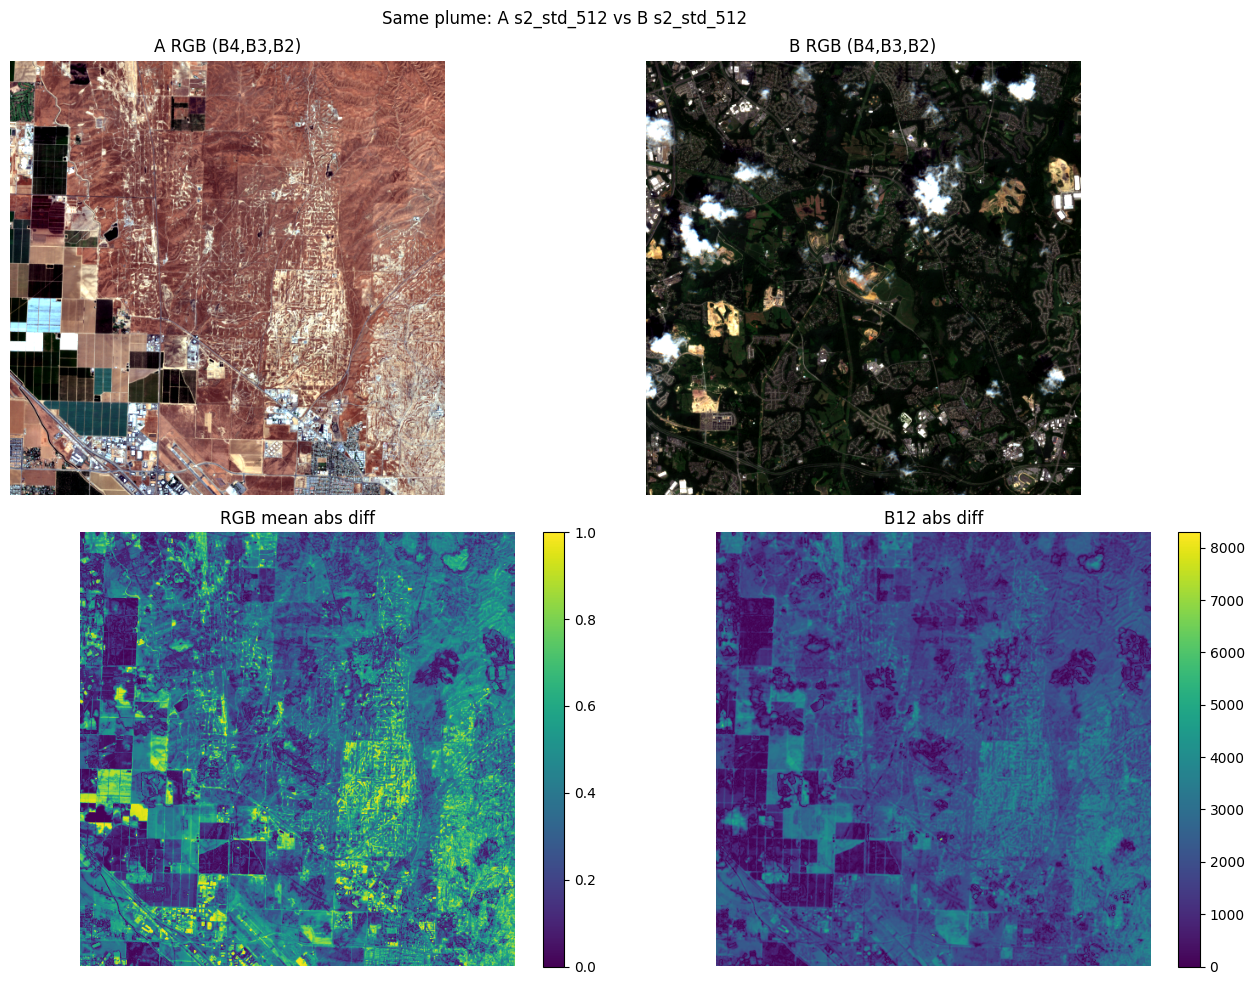

In [14]:
# compare
import os
import numpy as np
import tifffile as tiff
import rasterio
import matplotlib.pyplot as plt

# ================
# CONFIG (edit me)
# ================
# A_TIF = "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/plume_raw_s2_90360_fixed_512/av320250708t165600-B/s2_std_512.tif"
A_TIF = "/data2/yuyao/methane_emission/carbon_mapper_data/CM_S2_L2A/ang20170926t210253-D/s2.tif"
B_TIF = "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/plume_raw_s2_90360/av320250708t165600-B/s2.tif"

# Sentinel-2 band indices in your stored order (B1..B12) -> 0-based
BAND = {
    "B1": 0, "B2": 1, "B3": 2, "B4": 3, "B5": 4, "B6": 5,
    "B7": 6, "B8": 7, "B8A": 8, "B9": 9, "B11": 10, "B12": 11
}

def read_bhw(path):
    """Read tif as (B,H,W) using tifffile (safe for your data)."""
    arr = tiff.imread(path)
    if arr.ndim != 3:
        raise ValueError(f"{path} unexpected ndim={arr.ndim}, shape={arr.shape}")
    # infer BHW vs HWC
    if arr.shape[0] in (12, 13):
        bhw = arr
    elif arr.shape[-1] in (12, 13):
        bhw = np.transpose(arr, (2, 0, 1))
    else:
        raise ValueError(f"{path} can't infer bands-first/last, shape={arr.shape}")
    return bhw

def read_meta(path):
    """Read georef meta if possible (optional)."""
    meta = {}
    try:
        with rasterio.open(path) as ds:
            meta["crs"] = str(ds.crs)
            meta["transform"] = ds.transform
            meta["res"] = ds.res
            meta["dtype"] = str(ds.dtypes[0])
            meta["count"] = ds.count
            meta["shape_hw"] = (ds.height, ds.width)
    except Exception as e:
        meta["error"] = str(e)
    return meta

def summarize(arr, name):
    B,H,W = arr.shape
    flat = arr.reshape(B, -1).astype(np.float64)
    z = (flat == 0).mean(axis=1)
    print(f"\n[{name}] shape={arr.shape}, dtype={arr.dtype}, min={arr.min()}, max={arr.max()}")
    print(f"[{name}] zero_ratio per band:", np.round(z, 4))
    print(f"[{name}] global zero_ratio:", float((arr == 0).mean()))

def numeric_compare(a, b):
    """Return a bunch of diff metrics."""
    if a.shape != b.shape:
        return {"same_shape": False, "a_shape": a.shape, "b_shape": b.shape}

    same = np.array_equal(a, b)
    diff = (a.astype(np.int64) - b.astype(np.int64))  # safe for uint16
    absdiff = np.abs(diff)

    out = {
        "same_shape": True,
        "exact_equal": bool(same),
        "max_abs_diff": int(absdiff.max()),
        "mean_abs_diff": float(absdiff.mean()),
        "pct_nonzero_diff": float((absdiff != 0).mean()),
        "rmse": float(np.sqrt(np.mean((diff.astype(np.float64))**2))),
    }

    # per-band stats
    B = a.shape[0]
    out["per_band"] = []
    for bi in range(B):
        d = absdiff[bi]
        out["per_band"].append({
            "band": bi,
            "max_abs_diff": int(d.max()),
            "mean_abs_diff": float(d.mean()),
            "pct_nonzero_diff": float((d != 0).mean()),
        })
    return out

def edge_zero_ratio(arr, k=32):
    """Edge ring (k pixels) zero ratio per band."""
    B,H,W = arr.shape
    edge = np.concatenate([
        arr[:, :k, :].reshape(B, -1),
        arr[:, -k:, :].reshape(B, -1),
        arr[:, :, :k].reshape(B, -1),
        arr[:, :, -k:].reshape(B, -1),
    ], axis=1)
    return (edge == 0).mean(axis=1)

def to_rgb(arr_bhw, clip_p=(2, 98)):
    """
    Make a quick RGB composite using B4,B3,B2 (common).
    Output float in [0,1].
    """
    r = arr_bhw[BAND["B4"]].astype(np.float32)
    g = arr_bhw[BAND["B3"]].astype(np.float32)
    b = arr_bhw[BAND["B2"]].astype(np.float32)

    def norm(x):
        lo, hi = np.percentile(x, clip_p)
        if hi <= lo:
            return np.zeros_like(x, dtype=np.float32)
        x = (x - lo) / (hi - lo)
        return np.clip(x, 0, 1)

    rgb = np.stack([norm(r), norm(g), norm(b)], axis=-1)
    return rgb

def show_visual(a, b, title="A vs B"):
    """
    Show:
      1) A RGB
      2) B RGB
      3) RGB abs diff (mean over channels)
      4) band12 abs diff heatmap
    """
    rgb_a = to_rgb(a)
    rgb_b = to_rgb(b)
    rgb_diff = np.abs(rgb_a - rgb_b).mean(axis=-1)

    # band12 abs diff (B12)
    d12 = np.abs(a[BAND["B12"]].astype(np.int32) - b[BAND["B12"]].astype(np.int32))

    plt.figure(figsize=(14, 10))
    plt.subplot(2,2,1); plt.imshow(rgb_a); plt.title("A RGB (B4,B3,B2)"); plt.axis("off")
    plt.subplot(2,2,2); plt.imshow(rgb_b); plt.title("B RGB (B4,B3,B2)"); plt.axis("off")
    plt.subplot(2,2,3); plt.imshow(rgb_diff); plt.title("RGB mean abs diff"); plt.axis("off"); plt.colorbar(fraction=0.046, pad=0.04)
    plt.subplot(2,2,4); plt.imshow(d12); plt.title("B12 abs diff"); plt.axis("off"); plt.colorbar(fraction=0.046, pad=0.04)
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

def main():
    assert os.path.exists(A_TIF), f"Missing A: {A_TIF}"
    assert os.path.exists(B_TIF), f"Missing B: {B_TIF}"

    a = read_bhw(A_TIF)
    b = read_bhw(B_TIF)

    # ---- meta compare (optional) ----
    meta_a = read_meta(A_TIF)
    meta_b = read_meta(B_TIF)
    print("\n=== Rasterio meta (A) ===")
    for k,v in meta_a.items(): print(k, ":", v)
    print("\n=== Rasterio meta (B) ===")
    for k,v in meta_b.items(): print(k, ":", v)

    # ---- stats ----
    summarize(a, "A")
    summarize(b, "B")
    print("\n[A] edge_zero_ratio (k=32):", np.round(edge_zero_ratio(a, 32), 4))
    print("[B] edge_zero_ratio (k=32):", np.round(edge_zero_ratio(b, 32), 4))

    # ---- numeric compare ----
    cmp = numeric_compare(a, b)
    print("\n=== Numeric Compare ===")
    for k,v in cmp.items():
        if k == "per_band":
            continue
        print(f"{k}: {v}")

    if cmp.get("same_shape", False):
        print("\nPer-band diff (top 12):")
        for item in cmp["per_band"][:12]:
            print(item)

    # ---- visual ----
    if cmp.get("same_shape", False):
        show_visual(a, b, title="Same plume: A s2_std_512 vs B s2_std_512")

if __name__ == "__main__":
    main()


shape: (12, 512, 512) dtype: uint16
zero_ratio per band: [0.6933 0.6933 0.6933 0.6933 0.6933 0.6933 0.6933 0.6933 0.6933 0.6933
 0.6933 0.6933]
global zero_ratio: 0.6933199564615885
zero_any ratio: 0.6933479309082031
zero_all ratio: 0.6933174133300781


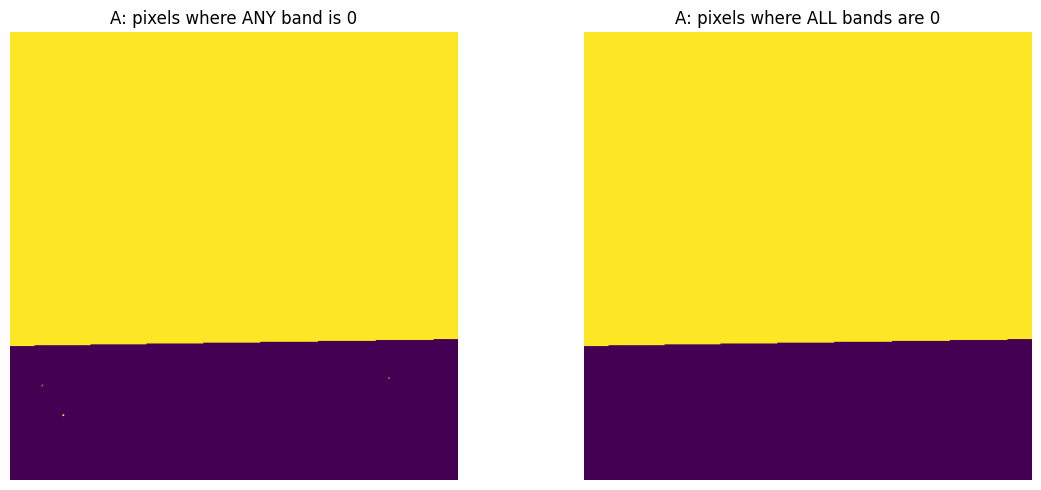

rasterio dataset_mask invalid ratio: 0.0


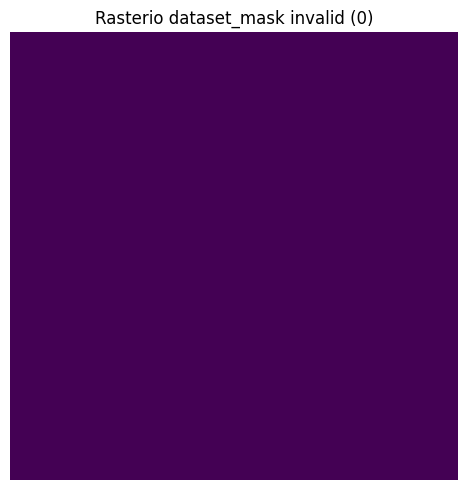

In [8]:
import numpy as np
import tifffile as tiff
import rasterio
import matplotlib.pyplot as plt

A_TIF = "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/plume_raw_s2_90360_fixed_512/av320250708t165600-B/s2_std_512.tif"

arr = tiff.imread(A_TIF)  # expect (12,512,512)
if arr.shape[-1] in (12,13):  # HWC
    arr = np.transpose(arr, (2,0,1))

B,H,W = arr.shape
print("shape:", arr.shape, "dtype:", arr.dtype)

# 1) per-band zero ratio
zr = (arr == 0).mean(axis=(1,2))
print("zero_ratio per band:", np.round(zr, 4))
print("global zero_ratio:", float((arr==0).mean()))

# 2) show zero map (any-band zero vs all-band zero)
zero_any = (arr == 0).any(axis=0)   # H,W
zero_all = (arr == 0).all(axis=0)   # H,W

print("zero_any ratio:", float(zero_any.mean()))
print("zero_all ratio:", float(zero_all.mean()))

plt.figure(figsize=(12,5))
plt.subplot(1,2,1); plt.imshow(zero_any); plt.title("A: pixels where ANY band is 0"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(zero_all); plt.title("A: pixels where ALL bands are 0"); plt.axis("off")
plt.tight_layout()
plt.show()

# 3) check rasterio mask/nodata consistency (if rasterio can read masks)
with rasterio.open(A_TIF) as ds:
    # dataset_mask: 0 = invalid, 255 = valid
    m = ds.dataset_mask()
    invalid = (m == 0)
    print("rasterio dataset_mask invalid ratio:", float(invalid.mean()))
    plt.figure(figsize=(6,5))
    plt.imshow(invalid)
    plt.title("Rasterio dataset_mask invalid (0)")
    plt.axis("off")
    plt.tight_layout()
    plt.show()


In [12]:
import rasterio
import pandas as pd

PLUME_ID = "av320250708t165600-B"
CSV = "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/plume_raw_s2_90360_fixed_512/raw_s2_90360_cleaned_fixed.csv"

df = pd.read_csv(CSV)

# 1) 找到这一行（plume_id 列名可能是 plume_id 或 id 等）
id_col_candidates = ["plume_id", "id", "sample_id"]
id_col = next((c for c in id_col_candidates if c in df.columns), None)
if id_col is None:
    raise ValueError(f"找不到 id 列，df.columns={list(df.columns)}")

rows = df[df[id_col].astype(str) == PLUME_ID]
if len(rows) == 0:
    raise ValueError(f"CSV 里没找到 {PLUME_ID}，请确认 {id_col} 列是否一致")
row = rows.iloc[0]

ps2 = row["s2_path"]  # 原图路径
lat = row["plume_latitude"]
lon = row["plume_longitude"]

print("Matched row index:", row.name)
print("s2_path:", ps2)
print("lat, lon:", lat, lon)

with rasterio.open(ps2) as src:
    r, c = src.index(lon, lat)
    print("image size (H,W):", src.height, src.width)
    print("center (row,col):", r, c)
    print("relative position (row/H, col/W):", r/src.height, c/src.width)
    print("bounds:", src.bounds)


Matched row index: 2852
s2_path: /data2/yuyao/methane_emission/carbonmapper_data_s2_l2a_complement_by_gee/av320250708t165600-B_s2.tif
lat, lon: 38.85298992249062 -76.79171289954797
image size (H,W): 514 655
center (row,col): 257 327
relative position (row/H, col/W): 0.5 0.49923664122137407
bounds: BoundingBox(left=-76.85051323031142, bottom=38.806860947849685, right=-76.73283392809176, top=38.89920775905717)


In [ ]:
# 2 划分训练集和测试集
import pandas as pd
all_csv = '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/plume_raw_s2_90360_fixed_512/raw_s2_90360_cleaned_fixed.csv'
df = pd.read_csv(all_csv)
df['date'] = pd.to_datetime(df['datetime'])
train_df = df[(df['date'] < '2023-08-20') & (df['date'] >= '2025-01-01')]  # 2025-04-01
test_df = df[(df['date'] >= '2023-08-20') & (df['date'] < '2025-01-01')]
            #  & (df['date'] < '2024-06-01')]
print(f'training set {len(train_df)} testing set {len(test_df)}')

# train_csv = '/data2/yuyao/methane_emission/data_csv/s2_90360_temporal_split_cleaned_gee2024/train.csv'
# train_df.to_csv(train_csv, index=False)
# print(f'train set size {len(train_df)}')

# test_csv = '/data2/yuyao/methane_emission/data_csv/s2_90360_temporal_split_cleaned_gee2024/test.csv'
# test_df.to_csv(test_csv, index=False)
# print(f'test set size {len(test_df)}')

training set 2532 testing set 716
train set size 2532
test set size 716


training set 4077 testing set 1090


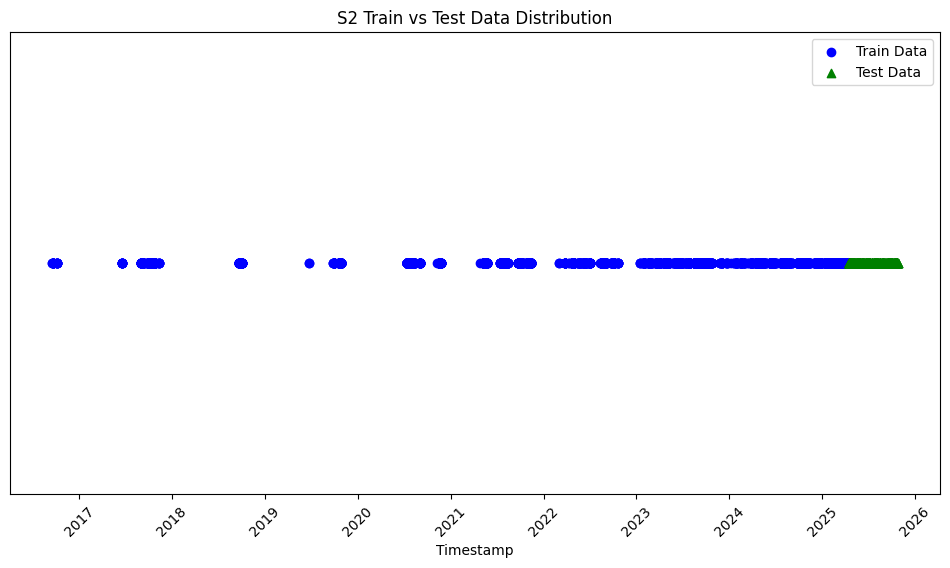

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

import pandas as pd
all_csv = '/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/plume_raw_s2_90360_fixed_512/raw_s2_90360_cleaned_fixed.csv'
df = pd.read_csv(all_csv)
df['date'] = pd.to_datetime(df['datetime'])
train_df = df[(df['date'] < '2025-04-15')]  #2025-04-15
test_df = df[(df['date'] >= '2025-04-15')]
print(f'training set {len(train_df)} testing set {len(test_df)}')

# 绘制数据
plt.figure(figsize=(12, 6))

plt.scatter(train_df['date'], [1] * len(train_df), color='blue', label='Train Data', marker='o')

# 绘制测试数据的散点图
plt.scatter(test_df['date'], [1] * len(test_df), color='green', label='Test Data', marker='^')

# 添加标题和标签
plt.title('S2 Train vs Test Data Distribution')
plt.xlabel('Timestamp')
plt.yticks([])  # 隐藏Y轴刻度，因为没有实际数值
plt.legend()

# 调整时间轴格式，使其更易读（可选）
plt.xticks(rotation=45)

# 显示图表
plt.show()


In [ ]:
# 5 从处理好的数据集中裁剪出训练样本40个正样本+40个负样本
import os
import pandas as pd
import numpy as np
import tifffile
import random
import threading
from concurrent.futures import ThreadPoolExecutor
import math
import imagecodecs  # keep if you need it

base_dir = "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/plume_s2_90360_32_gee2024"
train_csv_path = os.path.join(base_dir, "train.csv")
test_csv_path = os.path.join(base_dir, "test.csv")

origin_train_csv = "/data2/yuyao/methane_emission/data_csv/s2_90360_temporal_split_cleaned_gee2024/train.csv"
origin_test_csv = "/data2/yuyao/methane_emission/data_csv/s2_90360_temporal_split_cleaned_gee2024/test.csv"

os.makedirs(base_dir, exist_ok=True)

image_size = 32
band_index = 11  # 第12波段 (0-based in CHW)
zero_ratio_thresh = 0.20

N_POS = 8
N_NEG = 8

def to_chw(data):
    if data.ndim == 2:
        return data[None, :, :]
    if data.ndim != 3:
        return None
    # 更稳：优先用 bands=12/13 判断
    if data.shape[0] in (12, 13):        # CHW
        return data
    if data.shape[-1] in (12, 13):       # HWC
        return data.transpose(2, 0, 1)
    # fallback（尽量不炸）
    if data.shape[0] <= 20 and data.shape[0] < data.shape[-1]:
        return data
    return data.transpose(2, 0, 1)

def get_crop(width=512, height=512, center_size=20, crop_width=128):
    """
    Return (x, y): x = left (col), y = top (row)
    """
    center_x = width // 2
    center_y = height // 2
    center_left = center_x - center_size // 2
    center_right = center_x + center_size // 2
    center_top = center_y - center_size // 2
    center_bottom = center_y + center_size // 2

    left_min = max(0, center_right - crop_width)
    left_max = min(center_left, width - crop_width)
    top_min = max(0, center_bottom - crop_width)
    top_max = min(center_top, height - crop_width)

    x = random.randint(left_min, left_max)
    y = random.randint(top_min, top_max)
    return x, y

def is_center_contained(crop_xy, image_size=32, width=512, height=512, center_size=10):
    """
    crop_xy: (x, y)
    """
    center_x = width // 2
    center_y = height // 2

    cx1 = center_x - center_size // 2
    cy1 = center_y - center_size // 2
    cx2 = center_x + center_size // 2
    cy2 = center_y + center_size // 2

    x, y = crop_xy
    x1, y1 = x, y
    x2, y2 = x + image_size, y + image_size

    return (x1 <= cx1 and y1 <= cy1 and x2 >= cx2 and y2 >= cy2)

class ThreadSafeCounter:
    def __init__(self):
        self.lock = threading.Lock()
        self.counter = 0
    def increment(self):
        with self.lock:
            self.counter += 1
            return self.counter
    def get(self):
        with self.lock:
            return self.counter

def band12_zero_too_much(arr_chw):
    total = arr_chw[band_index].size
    if total == 0:
        return True
    zero_count = np.sum(arr_chw[band_index] == 0)
    return (zero_count / total) >= zero_ratio_thresh

def crop_chw(arr_chw, crop_xy, size):
    """
    arr_chw: (C,H,W)
    crop_xy: (x,y) where x=col, y=row
    """
    x, y = crop_xy
    return arr_chw[:, y:y+size, x:x+size]

def crop_hw(arr_hw, crop_xy, size):
    x, y = crop_xy
    return arr_hw[y:y+size, x:x+size]

def process_row(row, index, total_count, output_cnt, plume_cnt):
    t_data = to_chw(tifffile.imread(row["s2_path"]))
    t1_data = to_chw(tifffile.imread(row["s2_90_path"]))
    t2_data = to_chw(tifffile.imread(row["s2_360_path"]))
    mask = tifffile.imread(row["resized_512x512_path"])  # (H,W)

    if t_data is None or t1_data is None or t2_data is None or mask is None:
        return []

    data = []

    # 正样本 crop（包含中心区域）
    crop_list = [get_crop(crop_width=image_size) for _ in range(N_POS)]
    for crop_xy in crop_list:
        nt_data = crop_chw(t_data, crop_xy, image_size)
        nt1_data = crop_chw(t1_data, crop_xy, image_size)
        nt2_data = crop_chw(t2_data, crop_xy, image_size)
        n_mask  = crop_hw(mask, crop_xy, image_size)

        # 防止边界/异常导致尺寸不对
        if nt_data.shape[-2:] != (image_size, image_size) or n_mask.shape != (image_size, image_size):
            continue

        if band12_zero_too_much(nt_data) or band12_zero_too_much(nt1_data) or band12_zero_too_much(nt2_data):
            continue

        cnt = output_cnt.increment()
        dir_path = os.path.join(base_dir, str(cnt))
        os.makedirs(dir_path, exist_ok=True)

        nt_path = os.path.join(dir_path, "s2.tif")
        nt1_path = os.path.join(dir_path, "s2_90.tif")
        nt2_path = os.path.join(dir_path, "s2_360.tif")
        n_mask_path = os.path.join(dir_path, "plume.tif")

        tifffile.imwrite(nt_path, nt_data)
        tifffile.imwrite(nt1_path, nt1_data)
        tifffile.imwrite(nt2_path, nt2_data)
        tifffile.imwrite(n_mask_path, n_mask)

        data.append({
            "id": cnt,
            "s2_path": nt_path,
            "s2_90_path": nt1_path,
            "s2_360_path": nt2_path,
            "plume_mask_path": n_mask_path,
            "label": 1,
            "latitude": row["plume_latitude"],
            "longitude": row["plume_longitude"],
            "datetime": row["datetime"],
        })
        plume_cnt.increment()

    # 负样本 crop（随机）
    crop_list = [(random.randint(0, 512 - image_size), random.randint(0, 512 - image_size)) for _ in range(N_NEG)]
    for crop_xy in crop_list:
        nt_data = crop_chw(t_data, crop_xy, image_size)
        nt1_data = crop_chw(t1_data, crop_xy, image_size)
        nt2_data = crop_chw(t2_data, crop_xy, image_size)
        n_mask  = crop_hw(mask, crop_xy, image_size)

        if nt_data.shape[-2:] != (image_size, image_size) or n_mask.shape != (image_size, image_size):
            continue

        if band12_zero_too_much(nt_data) or band12_zero_too_much(nt1_data) or band12_zero_too_much(nt2_data):
            continue

        cnt = output_cnt.increment()
        dir_path = os.path.join(base_dir, str(cnt))
        os.makedirs(dir_path, exist_ok=True)

        nt_path = os.path.join(dir_path, "s2.tif")
        nt1_path = os.path.join(dir_path, "s2_90.tif")
        nt2_path = os.path.join(dir_path, "s2_360.tif")

        label = is_center_contained(crop_xy, image_size=image_size)
        if not label:
            n_mask = np.zeros((image_size, image_size), dtype=mask.dtype)
        else:
            plume_cnt.increment()

        n_mask_path = os.path.join(dir_path, "plume.tif")

        tifffile.imwrite(nt_path, nt_data)
        tifffile.imwrite(nt1_path, nt1_data)
        tifffile.imwrite(nt2_path, nt2_data)
        tifffile.imwrite(n_mask_path, n_mask)

        data.append({
            "id": cnt,
            "s2_path": nt_path,
            "s2_90_path": nt1_path,
            "s2_360_path": nt2_path,
            "plume_mask_path": n_mask_path,
            "label": 0 if not label else 1,
            "latitude": row["plume_latitude"],
            "longitude": row["plume_longitude"],
            "datetime": row["datetime"],
        })

    print(f"processed {index} / {total_count} plume_cnt {plume_cnt.get()} / {output_cnt.get()}")
    return data

def run_split(csv_path, out_csv_path, output_cnt, plume_cnt):
    org_df = pd.read_csv(csv_path)
    data_all = []

    batch_size = 32
    total_rows = len(org_df)
    num_batches = math.ceil(total_rows / batch_size)

    for batch_num in range(num_batches):
        start_idx = batch_num * batch_size
        end_idx = min((batch_num + 1) * batch_size, total_rows)
        batch_df = org_df.iloc[start_idx:end_idx]

        futures = []
        with ThreadPoolExecutor(max_workers=16) as executor:
            for index, row in batch_df.iterrows():
                futures.append(executor.submit(process_row, row, index, total_rows, output_cnt, plume_cnt))
            for future in futures:
                data_all.extend(future.result())

    out_df = pd.DataFrame(data_all)
    out_df.to_csv(out_csv_path, index=False)
    print(f"wrote {out_csv_path}, size={len(out_df)}")
    return out_df

output_cnt = ThreadSafeCounter()
plume_cnt = ThreadSafeCounter()

train_df = run_split(origin_train_csv, train_csv_path, output_cnt, plume_cnt)
test_df = run_split(origin_test_csv, test_csv_path, output_cnt, plume_cnt)

print(f"total count: {len(train_df) + len(test_df)}")
print(f"train label sum: {train_df['label'].sum()} / {len(train_df)}")
print(f"test label sum: {test_df['label'].sum()} / {len(test_df)}")

processed 12 / 4116 plume_cnt 128 / 208
processed 8 / 4116 plume_cnt 128 / 248
processed 2 / 4116 plume_cnt 129 / 249
processed 6 / 4116 plume_cnt 129 / 250
processed 9 / 4116 plume_cnt 129 / 250
processed 7 / 4116 plume_cnt 129 / 251
processed 10 / 4116 plume_cnt 129 / 252
processed 5 / 4116 plume_cnt 129 / 253
processed 4 / 4116 plume_cnt 129 / 254
processed 1 / 4116 plume_cnt 130 / 255
processed 15 / 4116 plume_cnt 130 / 257
processed 11 / 4116 plume_cnt 130 / 257
processed 20 / 4116 plume_cnt 130 / 258
processed 14 / 4116 plume_cnt 130 / 258
processed 3 / 4116 plume_cnt 130 / 258
processed 13 / 4116 plume_cnt 130 / 260
processed 25 / 4116 plume_cnt 130 / 260
processed 0 / 4116 plume_cnt 132 / 265
processed 16 / 4116 plume_cnt 240 / 442
processed 29 / 4116 plume_cnt 240 / 454
processed 28 / 4116 plume_cnt 240 / 457
processed 18 / 4116 plume_cnt 240 / 462
processed 24 / 4116 plume_cnt 240 / 467
processed 26 / 4116 plume_cnt 240 / 468
processed 22 / 4116 plume_cnt 240 / 468
processed 

In [2]:
import pandas as pd
df =pd.read_csv("/data2/yuyao/methane_emission/preprocess_dataset_s2/manifest_minus7_plume_to_safe.csv")
print(df['raw_dir_exists'].sum())

3155.0


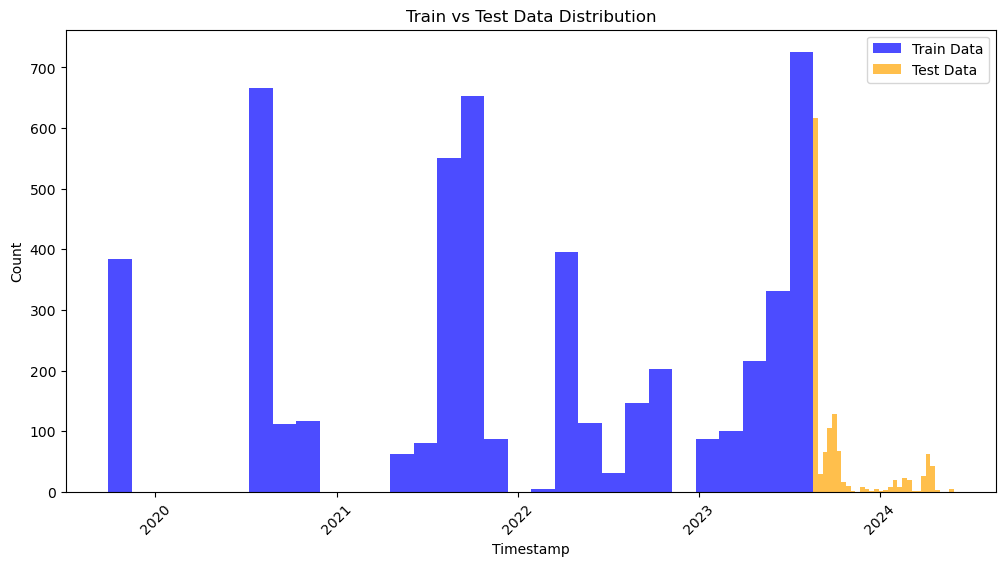

In [3]:
train_data = df[(df['date'] < '2023-08-20')]['date']
test_data = df[(df['date'] >= '2023-08-20')]['date']

plt.figure(figsize=(12, 6))

# 绘制训练数据和测试数据的直方图
plt.hist(train_data, bins=30, alpha=0.7, label='Train Data', color='blue')
plt.hist(test_data, bins=30, alpha=0.7, label='Test Data', color='orange')

# 添加标题和标签
plt.title('Train vs Test Data Distribution')
plt.xlabel('Timestamp')
plt.ylabel('Count')
plt.legend()

# 调整时间轴格式
plt.xticks(rotation=45)

# 显示图表
plt.show()

In [4]:
import pandas as pd
train_csv_path = '/storage/hongxuan/carbonmapper_s2/carbonmapper_3_90_test_data_classification_location/train.csv'
test_csv_path = '/storage/hongxuan/carbonmapper_s2/carbonmapper_3_90_test_data_classification_location/test.csv'
train_df = pd.read_csv(train_csv_path)
train_plume_df = train_df[train_df['label'] == 1]
print(f'train set size {len(train_plume_df)}/{len(train_df)}')

test_df = pd.read_csv(test_csv_path)
test_plume_df = test_df[test_df['label'] == 1]
print(f'test set size {len(test_plume_df)}/{len(test_df)}')

train set size 47853/96106
test set size 10671/20805


    latitude_center  longitude_center  cluster
0         32.025415       -102.472451        0
1         31.409842         47.819403        1
2         30.940793          5.351986        2
3        -34.896643        -69.699012        3
4         38.289140       -108.310040        4
5         35.724409        108.985170        5
6         35.726835       -119.517861        6
7         40.013858        -80.591491        7
8         39.191839         60.554444        8
9         30.830023         31.822978        9
10       -25.597949        149.236048       10
11        30.957061         76.934142       11
12        47.326754       -118.850943       12
13         9.753137        -73.442117       13
14        40.191390       -104.563848       14
15        41.337481        -88.323371       15
16        33.592756        -85.509143       16
17       -22.613021        -47.420267       17
18       -25.458609         28.110487       18
19        29.313593        -92.717572       19


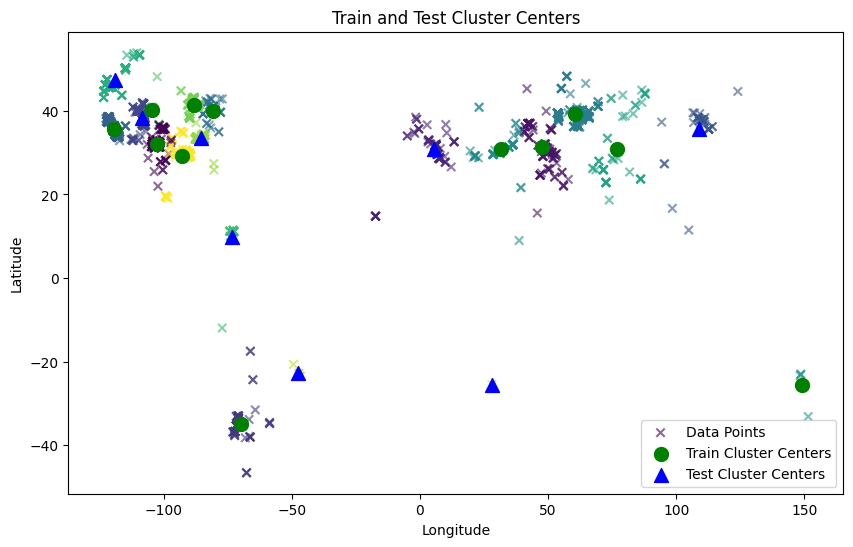

训练集样本数量: 5043
测试集样本数量: 1304
train set size 5043
test set size 1304


In [2]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

all_csv = '/storage/hongxuan/carbonmapper_s2/carbon_mapper_3_90_365_l2a_test_extraction/all.csv'
df = pd.read_csv(all_csv)

n_clusters = 20

kmeans = KMeans(n_clusters=n_clusters, random_state=0)
df['cluster'] = kmeans.fit_predict(df[['latitude', 'longitude']])

# 获取聚类中心
cluster_centers = kmeans.cluster_centers_

# 将聚类中心转换为DataFrame以便查看
centers_df = pd.DataFrame(cluster_centers, columns=['latitude_center', 'longitude_center'])
centers_df['cluster'] = centers_df.index 
# 查看聚类中心
print(centers_df)

train_clusters, test_clusters = train_test_split(
    df['cluster'].unique(), test_size=0.4, random_state=0
)

# 根据聚类结果创建训练集和测试集
train_df = df[df['cluster'].isin(train_clusters)].reset_index(drop=True)
test_df = df[df['cluster'].isin(test_clusters)].reset_index(drop=True)

train_centers = centers_df[centers_df['cluster'].isin(train_clusters)]
test_centers = centers_df[centers_df['cluster'].isin(test_clusters)]

plt.figure(figsize=(10, 6))
plt.scatter(df['longitude'], df['latitude'], c=df['cluster'], cmap='viridis', marker='x', alpha=0.6, label='Data Points')
# 绘制训练集的聚类中心（绿色圆圈）
plt.scatter(train_centers['longitude_center'], train_centers['latitude_center'], 
            c='green', marker='o', s=100, label='Train Cluster Centers')

# 绘制测试集的聚类中心（蓝色三角形）
plt.scatter(test_centers['longitude_center'], test_centers['latitude_center'], 
            c='blue', marker='^', s=100, label='Test Cluster Centers')

# 添加标题和标签
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Train and Test Cluster Centers')
plt.legend()

# 显示图像
plt.show()




# 查看结果
print("训练集样本数量:", len(train_df))
print("测试集样本数量:", len(test_df))

train_csv = '/storage/hongxuan/carbonmapper_s2/carbon_mapper_3_90_365_l2a_test_extraction_location/train.csv'
train_df.to_csv(train_csv, index=False)
print(f'train set size {len(train_df)}')

test_csv = '/storage/hongxuan/carbonmapper_s2/carbon_mapper_3_90_365_l2a_test_extraction_location/test.csv'
test_df.to_csv(test_csv, index=False)
print(f'test set size {len(test_df)}')

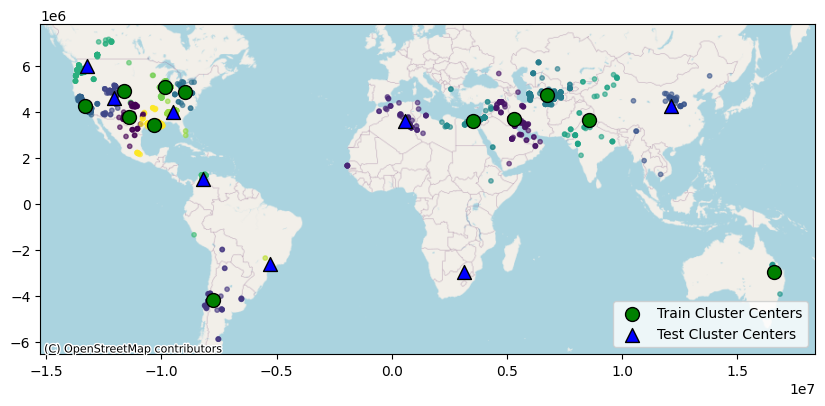

In [3]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import geopandas as gpd
import contextily as ctx
# 将数据和聚类中心转换为 GeoDataFrame
gdf = gpd.GeoDataFrame(df, 
                       geometry=gpd.points_from_xy(df['longitude'], df['latitude']),
                       crs="EPSG:4326")

train_centers_gdf = gpd.GeoDataFrame(train_centers, 
                                     geometry=gpd.points_from_xy(train_centers['longitude_center'], 
                                                                 train_centers['latitude_center']),
                                     crs="EPSG:4326")

test_centers_gdf = gpd.GeoDataFrame(test_centers, 
                                    geometry=gpd.points_from_xy(test_centers['longitude_center'], 
                                                                test_centers['latitude_center']),
                                    crs="EPSG:4326")

# 转换坐标系为 Web Mercator
gdf = gdf.to_crs(epsg=3857)
train_centers_gdf = train_centers_gdf.to_crs(epsg=3857)
test_centers_gdf = test_centers_gdf.to_crs(epsg=3857)

# 创建绘图
fig, ax = plt.subplots(figsize=(10, 6))

# 绘制数据点（使用 cluster 进行颜色区分）
gdf.plot(ax=ax, column='cluster', cmap='viridis', markersize=10, alpha=0.6, legend=False)

# 绘制训练集的聚类中心（绿色圆圈）
train_centers_gdf.plot(ax=ax, color='green', marker='o', markersize=100, edgecolor='black', label='Train Cluster Centers')

# 绘制测试集的聚类中心（蓝色三角形）
test_centers_gdf.plot(ax=ax, color='blue', marker='^', markersize=100, edgecolor='black', label='Test Cluster Centers')

# 添加地图底图
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

# 添加标题和标签
# plt.xlabel('X (meters, Web Mercator)', fontsize = 14)
# plt.ylabel('Y (meters, Web Mercator)', fontsize = 14)
# plt.title('Train and Test Cluster Centers with Data Points')
plt.legend()

# 显示图像
plt.show()

In [ ]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import rasterio
import tifffile
import json
import random
import threading
from concurrent.futures import ThreadPoolExecutor
import math

base_dir = '/home/hongxuan/methane/carbonmapper_3_90_365_l2a_test_data_classification_temporal_16'
train_csv_path = '/home/hongxuan/methane/carbonmapper_3_90_365_l2a_test_data_classification_temporal_16/train.csv'
origin_train_csv = '/storage/hongxuan/carbonmapper_s2/carbon_mapper_3_90_365_l2a_test_extraction_temporal/train.csv'
test_csv_path = '/home/hongxuan/methane/carbonmapper_3_90_365_l2a_test_data_classification_temporal_16/test.csv'
origin_test_csv = '/storage/hongxuan/carbonmapper_s2/carbon_mapper_3_90_365_l2a_test_extraction_temporal/test.csv'

os.makedirs(base_dir, exist_ok=True)

def get_crop(width = 512, height = 512, center_size = 10, crop_width = 128):
    
    center_x = width // 2
    center_y = height // 2

    # 中心区域的边界坐标
    center_left = center_x - center_size // 2
    center_right = center_x + center_size // 2
    center_top = center_y - center_size // 2
    center_bottom = center_y + center_size // 2

    # 确保裁剪区域完全包含中心20x20的区域
    # 裁剪区域的左上角坐标 (left, top) 的范围
    left_min = max(0, center_right - crop_width)  # left的最小值，确保右边界在中心的右侧
    left_max = min(center_left, width - crop_width)  # left的最大值，确保左边界在中心的左侧

    top_min = max(0, center_bottom - crop_width)  # top的最小值，确保下边界在中心的下侧
    top_max = min(center_top, height - crop_width)  # top的最大值，确保上边界在中心的上侧

    # 随机选取裁剪区域的左上角坐标
    left = random.randint(left_min, left_max)
    top = random.randint(top_min, top_max)

    return left, top


data = []

image_size = 16

cnt = 0
plume_cnt = 0
org_train_df = pd.read_csv(origin_train_csv)
# crop_list = [(0, 0), (0, 512 - 96), (512 - 96, 512 - 96), (512 - 96, 0), (256 - 96, 256 - 96), (256 - 96, 256), (256, 256), (256, 256 - 96)]

class ThreadSafeCounter():
    def __init__(self):
        self.lock = threading.Lock()
        self.counter = 0
    def increment(self):
        with self.lock:
            self.counter += 1
            return self.counter
    def get(self):
        with self.lock:
            return self.counter

def is_center_contained(crop, image_size = 128, width = 512, height = 512):

    center_x = width // 2
    center_y = height // 2
    center_size = 10

    # 中心区域的边界坐标
    center_x1 = center_x - center_size // 2
    center_y1 = center_y - center_size // 2
    center_x2 = center_x + center_size // 2
    center_y2= center_y + center_size // 2
    
    crop_x1 = crop[0]
    crop_y1 = crop[1]
    crop_x2 = crop[0] + image_size
    crop_y2 = crop[1] + image_size
    
    # 判断大矩形是否包含小矩形
    if (crop_x1 <= center_x1 and crop_y1 <= center_y1 and
        crop_x2 >= center_x2 and crop_y2 >= center_y2):
        return True
    else:
        return False

def process_row(row, index, total_count, output_cnt, plume_cnt):
    t_data = tifffile.imread(row['s2_path'])
    t_data = t_data.transpose(2, 0, 1)
    # total_elements = t_data[12].size
    # zero_count = np.sum(t_data[12] == 0)
    # if zero_count >= (total_elements // 5):
    #     continue
    t1_data = tifffile.imread(row['s2_pre_path'])
    t1_data = t1_data.transpose(2, 0, 1)
    t2_data = tifffile.imread(row['s2_pre_pre_path'])
    t2_data = t2_data.transpose(2, 0, 1)
    mask = tifffile.imread(row['plume_mask_path'])
    data = []
    crop_list = []
    for i in range(8):
        crop_list.append(get_crop(crop_width = image_size))
    
    for crop in crop_list:
        nt_data = t_data[:,crop[0]:crop[0]+image_size,crop[1]:crop[1]+image_size]
        nt1_data = t1_data[:,crop[0]:crop[0]+image_size,crop[1]:crop[1]+image_size]
        nt2_data = t2_data[:,crop[0]:crop[0]+image_size,crop[1]:crop[1]+image_size]
        n_mask = mask[crop[0]:crop[0]+image_size, crop[1]:crop[1]+image_size]

        total_elements = nt_data[11].size
        zero_count = np.sum(nt_data[11] == 0)
        if zero_count >= (total_elements // 4):
            continue
        total_elements = nt1_data[11].size
        zero_count = np.sum(nt1_data[11] == 0)
        if zero_count >= (total_elements // 4):
            continue
        total_elements = nt2_data[11].size
        zero_count = np.sum(nt2_data[11] == 0)
        if zero_count >= (total_elements // 4):
            continue
        cnt = output_cnt.increment()
        dir_path = os.path.join(base_dir, str(cnt))
        os.makedirs(dir_path, exist_ok=True)
        nt_path = os.path.join(base_dir, str(cnt), "s2.tif")
        tifffile.imwrite(nt_path, nt_data)
        nt1_path = os.path.join(base_dir, str(cnt), "s2_pre.tif")
        tifffile.imwrite(nt1_path, nt1_data)
        nt2_path = os.path.join(base_dir, str(cnt), "s2_pre_pre.tif")
        tifffile.imwrite(nt2_path, nt2_data)
        n_mask_path = os.path.join(base_dir, str(cnt), "plume.tif")
        tifffile.imwrite(n_mask_path, n_mask)
        # , "s2_post_path": nt2_path
        data.append({"id": cnt, "s2_path": nt_path, "s2_pre_path": nt1_path, "s2_pre_pre_path": nt2_path, "plume_mask_path": n_mask_path, "label": 1, "emission_auto": row['emission_auto'], "emission_uncertainty_auto": row['emission_uncertainty_auto'], 'latitude': row['latitude'], 'longitude': row['longitude']})
        plume_cnt.increment()
    crop_list = []
    for i in range(8):
        crop_list.append((random.randint(0, 512 - image_size), random.randint(0, 512 - image_size)))

    # plt.imshow(t_data[12])
    # plt.colorbar(label='MBMP')
    # plt.title('Band 12')
    # plt.show()

    for crop in crop_list:
        nt_data = t_data[:,crop[0]:crop[0]+image_size,crop[1]:crop[1]+image_size]
        nt1_data = t1_data[:,crop[0]:crop[0]+image_size,crop[1]:crop[1]+image_size]
        nt2_data = t2_data[:,crop[0]:crop[0]+image_size,crop[1]:crop[1]+image_size]
        n_mask = mask[crop[0]:crop[0]+image_size, crop[1]:crop[1]+image_size]

        total_elements = nt_data[11].size
        zero_count = np.sum(nt_data[11] == 0)
        if zero_count >= (total_elements // 4):
            continue
        total_elements = nt1_data[11].size
        zero_count = np.sum(nt1_data[11] == 0)
        if zero_count >= (total_elements // 4):
            continue
        total_elements = nt2_data[11].size
        zero_count = np.sum(nt2_data[11] == 0)
        if zero_count >= (total_elements // 4):
            continue
        cnt = output_cnt.increment()
        dir_path = os.path.join(base_dir, str(cnt))
        os.makedirs(dir_path, exist_ok=True)
        nt_path = os.path.join(base_dir, str(cnt), "s2.tif")
        tifffile.imwrite(nt_path, nt_data)
        nt1_path = os.path.join(base_dir, str(cnt), "s2_pre.tif")
        tifffile.imwrite(nt1_path, nt1_data)
        nt2_path = os.path.join(base_dir, str(cnt), "s2_pre_pre.tif")
        tifffile.imwrite(nt2_path, nt2_data)

        label = is_center_contained(crop, image_size = image_size)
        if not label:
            n_mask = np.zeros((image_size, image_size))
        else:
            plume_cnt.increment()

        n_mask_path = os.path.join(base_dir, str(cnt), "plume.tif")
        tifffile.imwrite(n_mask_path, n_mask)
        
        # , "s2_post_path": nt2_path
        data.append({"id": cnt, "s2_path": nt_path, "s2_pre_path": nt1_path, "s2_pre_pre_path": nt2_path, "plume_mask_path": n_mask_path, "label": 0 if not label else 1, "emission_auto": 0 if not label else row['emission_auto'], "emission_uncertainty_auto": 0 if not label else row['emission_uncertainty_auto'], 'latitude': row['latitude'], 'longitude': row['longitude']})
    print(f'processed {index} / {total_count} plume_cnt {plume_cnt.get()} / {output_cnt.get()}')
    return data

data_train = []
futures = []
output_cnt = ThreadSafeCounter()
plume_cnt = ThreadSafeCounter()
# with ThreadPoolExecutor(max_workers=16) as executor:
#     for index, row in org_train_df.iterrows():
#         futures.append(executor.submit(process_row, row, index, len(org_train_df), output_cnt, plume_cnt))

#     for future in futures:
#         data_train.extend(future.result())
batch_size = 32
total_rows = len(org_train_df)
num_batches = math.ceil(total_rows / batch_size)

for batch_num in range(num_batches):
    start_idx = batch_num * batch_size
    end_idx = min((batch_num + 1) * batch_size, total_rows)

    batch_df = org_train_df.iloc[start_idx:end_idx]
    futures = []

    with ThreadPoolExecutor(max_workers=16) as executor:
        for index, row in batch_df.iterrows():
            futures.append(executor.submit(process_row, row, index, total_rows, output_cnt, plume_cnt))

        for future in futures:
            data_train.extend(future.result())
    
train_df = pd.DataFrame(data_train)
train_df.to_csv(train_csv_path, index=False)
print(f'training set count: {len(data_train)}')


data_test = []
futures = []
org_test_df = pd.read_csv(origin_test_csv)
# with ThreadPoolExecutor(max_workers=16) as executor:
#     for index, row in org_test_df.iterrows():
#         futures.append(executor.submit(process_row, row, index, len(org_test_df), output_cnt, plume_cnt))

#     for future in futures:
#         data_test.extend(future.result())

batch_size = 32
total_rows = len(org_test_df)
num_batches = math.ceil(total_rows / batch_size)

for batch_num in range(num_batches):
    start_idx = batch_num * batch_size
    end_idx = min((batch_num + 1) * batch_size, total_rows)

    batch_df = org_test_df.iloc[start_idx:end_idx]
    futures = []

    with ThreadPoolExecutor(max_workers=16) as executor:
        for index, row in batch_df.iterrows():
            futures.append(executor.submit(process_row, row, index, total_rows, output_cnt, plume_cnt))

        for future in futures:
            data_test.extend(future.result())


test_df = pd.DataFrame(data_test)
test_df.to_csv(test_csv_path, index=False)
print(f'total count: {len(data_train) + len(data_test)}')

column_sum = train_df['label'].sum()
print(f"label: {column_sum} total {len(train_df)}")

column_sum = test_df['label'].sum()
print(f"label: {column_sum} total {len(test_df)}")

processed 1 / 5067 plume_cnt 107 / 139
processed 6 / 5067 plume_cnt 117 / 157
processed 0 / 5067 plume_cnt 128 / 190
processed 3 / 5067 plume_cnt 128 / 229
processed 5 / 5067 plume_cnt 128 / 230
processed 10 / 5067 plume_cnt 128 / 232
processed 2 / 5067 plume_cnt 128 / 234
processed 15 / 5067 plume_cnt 128 / 237
processed 12 / 5067 plume_cnt 128 / 245
processed 8 / 5067 plume_cnt 128 / 247
processed 9 / 5067 plume_cnt 128 / 247
processed 7 / 5067 plume_cnt 128 / 248
processed 4 / 5067 plume_cnt 128 / 250
processed 14 / 5067 plume_cnt 128 / 252
processed 11 / 5067 plume_cnt 128 / 252
processed 13 / 5067 plume_cnt 128 / 252
processed 17 / 5067 plume_cnt 144 / 282
processed 16 / 5067 plume_cnt 144 / 282
processed 23 / 5067 plume_cnt 253 / 452
processed 20 / 5067 plume_cnt 256 / 469
processed 19 / 5067 plume_cnt 256 / 472
processed 22 / 5067 plume_cnt 256 / 472
processed 18 / 5067 plume_cnt 256 / 480
processed 21 / 5067 plume_cnt 256 / 481
processed 31 / 5067 plume_cnt 256 / 482
processed 

In [4]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import rasterio
import tifffile
import json
import random
import threading
from concurrent.futures import ThreadPoolExecutor

base_dir = '/storage/hongxuan/carbonmapper_s2/carbonmapper_3_90_365_test_data_classification_temporal_permian'
train_csv_path = '/storage/hongxuan/carbonmapper_s2/carbonmapper_3_90_365_test_data_classification_temporal_permian/train.csv'
origin_train_csv = '/storage/hongxuan/carbonmapper_s2/carbon_mapper_3_90_365_test_extraction_permian_temporal/train.csv'
test_csv_path = '/storage/hongxuan/carbonmapper_s2/carbonmapper_3_90_365_test_data_classification_temporal_permian/test.csv'
origin_test_csv = '/storage/hongxuan/carbonmapper_s2/carbon_mapper_3_90_365_test_extraction_permian_temporal/test.csv'

os.makedirs(base_dir, exist_ok=True)

def get_crop(width = 512, height = 512, center_size = 20, crop_width = 128, crop_height = 128):
    
    center_x = width // 2
    center_y = height // 2

    # 中心区域的边界坐标
    center_left = center_x - center_size // 2
    center_right = center_x + center_size // 2
    center_top = center_y - center_size // 2
    center_bottom = center_y + center_size // 2

    # 确保裁剪区域完全包含中心20x20的区域
    # 裁剪区域的左上角坐标 (left, top) 的范围
    left_min = max(0, center_right - crop_width)  # left的最小值，确保右边界在中心的右侧
    left_max = min(center_left, width - crop_width)  # left的最大值，确保左边界在中心的左侧

    top_min = max(0, center_bottom - crop_height)  # top的最小值，确保下边界在中心的下侧
    top_max = min(center_top, height - crop_height)  # top的最大值，确保上边界在中心的上侧

    # 随机选取裁剪区域的左上角坐标
    left = random.randint(left_min, left_max)
    top = random.randint(top_min, top_max)

    return left, top


data = []

image_size = 128

cnt = 0
plume_cnt = 0
org_train_df = pd.read_csv(origin_train_csv)
# crop_list = [(0, 0), (0, 512 - 96), (512 - 96, 512 - 96), (512 - 96, 0), (256 - 96, 256 - 96), (256 - 96, 256), (256, 256), (256, 256 - 96)]

class ThreadSafeCounter():
    def __init__(self):
        self.lock = threading.Lock()
        self.counter = 0
    def increment(self):
        with self.lock:
            self.counter += 1
            return self.counter
    def get(self):
        with self.lock:
            return self.counter


def process_row(row, index, total_count, output_cnt, plume_cnt):
    t_data = tifffile.imread(row['s2_path'])
    t_data = t_data.transpose(2, 0, 1)
    # total_elements = t_data[12].size
    # zero_count = np.sum(t_data[12] == 0)
    # if zero_count >= (total_elements // 5):
    #     continue
    t1_data = tifffile.imread(row['s2_pre_path'])
    t1_data = t1_data.transpose(2, 0, 1)
    t2_data = tifffile.imread(row['s2_pre_pre_path'])
    t2_data = t2_data.transpose(2, 0, 1)
    mask = tifffile.imread(row['plume_mask_path'])
    data = []
    crop_list = []
    for i in range(8):
        crop_list.append(get_crop())
    for i in range(12):
        crop_list.append((random.randint(0, 374), random.randint(0, 374)))

    # plt.imshow(t_data[12])
    # plt.colorbar(label='MBMP')
    # plt.title('Band 12')
    # plt.show()

    for crop in crop_list:
        nt_data = t_data[:,crop[0]:crop[0]+image_size,crop[1]:crop[1]+image_size]
        nt1_data = t1_data[:,crop[0]:crop[0]+image_size,crop[1]:crop[1]+image_size]
        nt2_data = t2_data[:,crop[0]:crop[0]+image_size,crop[1]:crop[1]+image_size]
        n_mask = mask[crop[0]:crop[0]+image_size, crop[1]:crop[1]+image_size]

        total_elements = nt_data[12].size
        zero_count = np.sum(nt_data[12] == 0)
        # print(f'{zero_count} / {total_elements}')
        if zero_count >= (total_elements // 2):
            continue
        cnt = output_cnt.increment()
        dir_path = os.path.join(base_dir, str(cnt))
        os.makedirs(dir_path, exist_ok=True)
        nt_path = os.path.join(base_dir, str(cnt), "s2.tif")
        tifffile.imwrite(nt_path, nt_data)
        nt1_path = os.path.join(base_dir, str(cnt), "s2_-5.tif")
        tifffile.imwrite(nt1_path, nt1_data)
        nt2_path = os.path.join(base_dir, str(cnt), "s2_pre_pre.tif")
        tifffile.imwrite(nt2_path, nt2_data)
        n_mask_path = os.path.join(base_dir, str(cnt), "plume.tif")
        tifffile.imwrite(n_mask_path, n_mask)
        mask_sum = np.sum(n_mask)
        # , "s2_post_path": nt2_path
        data.append({"id": cnt, "s2_path": nt_path, "s2_pre_path": nt1_path, "s2_pre_pre_path": nt2_path, "plume_mask_path": n_mask_path, "label": 0 if mask_sum == 0 else 1, "emission_auto": 0 if mask_sum == 0 else row['emission_auto'], "emission_uncertainty_auto": 0 if mask_sum == 0 else row['emission_uncertainty_auto'], 'latitude': row['latitude'], 'longitude': row['longitude']})
        if mask_sum != 0:
            plume_cnt.increment()
    print(f'processed {index} / {total_count} plume_cnt {plume_cnt.get()} / {output_cnt.get()}')
    return data

data_train = []
futures = []
output_cnt = ThreadSafeCounter()
plume_cnt = ThreadSafeCounter()
with ThreadPoolExecutor(max_workers=32) as executor:
    for index, row in org_train_df.iterrows():
        futures.append(executor.submit(process_row, row, index, len(org_train_df), output_cnt, plume_cnt))

    for future in futures:
        data_train.extend(future.result())
    
train_df = pd.DataFrame(data_train)
train_df.to_csv(train_csv_path, index=False)
print(f'training set count: {len(data_train)}')


data_test = []
futures = []
org_test_df = pd.read_csv(origin_test_csv)
with ThreadPoolExecutor(max_workers=32) as executor:
    for index, row in org_test_df.iterrows():
        futures.append(executor.submit(process_row, row, index, len(org_test_df), output_cnt, plume_cnt))

    for future in futures:
        data_test.extend(future.result())


test_df = pd.DataFrame(data_test)
test_df.to_csv(test_csv_path, index=False)
print(f'total count: {len(data_train) + len(data_test)}')

column_sum = train_df['label'].sum()
print(f"label: {column_sum} total {len(train_df)}")

column_sum = test_df['label'].sum()
print(f"label: {column_sum} total {len(test_df)}")

processed 27 / 2577 plume_cnt 301 / 588
processed 14 / 2577 plume_cnt 301 / 596
processed 13 / 2577 plume_cnt 302 / 603
processed 12 / 2577 plume_cnt 302 / 612
processed 26 / 2577 plume_cnt 305 / 615
processed 25 / 2577 plume_cnt 305 / 617
processed 11 / 2577 plume_cnt 306 / 623
processed 7 / 2577 plume_cnt 307 / 628
processed 23 / 2577 plume_cnt 307 / 628
processed 15 / 2577 plume_cnt 307 / 628
processed 28 / 2577 plume_cnt 308 / 640
processed 19 / 2577 plume_cnt 309 / 640
processed 18 / 2577 plume_cnt 309 / 641
processed 16 / 2577 plume_cnt 309 / 641
processed 21 / 2577 plume_cnt 309 / 641
processed 3 / 2577 plume_cnt 309 / 641
processed 9 / 2577 plume_cnt 309 / 642
processed 5 / 2577 plume_cnt 311 / 645
processed 4 / 2577 plume_cnt 311 / 645
processed 6 / 2577 plume_cnt 312 / 646
processed 29 / 2577 plume_cnt 312 / 647
processed 20 / 2577 plume_cnt 312 / 648
processed 8 / 2577 plume_cnt 312 / 648
processed 17 / 2577 plume_cnt 312 / 648
processed 31 / 2577 plume_cnt 312 / 648
process

In [1]:
import pandas as pd
train_csv_path = '/storage/hongxuan/carbonmapper_s2/carbonmapper_3_90_365_test_data_classification_temporal_permian/train.csv'
test_csv_path = '/storage/hongxuan/carbonmapper_s2/carbonmapper_3_90_365_test_data_classification_temporal_permian/test.csv'

train_df = pd.read_csv(train_csv_path)
test_df = pd.read_csv(test_csv_path)


column_sum = train_df['label'].sum()
print(f"label: {column_sum} total {len(train_df)}")

column_sum = test_df['label'].sum()
print(f"label: {column_sum} total {len(test_df)}")

label: 27210 total 55596
label: 5579 total 11247


In [ ]:
import os
import pandas as pd
import numpy as np
import tifffile
import random
import threading
from concurrent.futures import ThreadPoolExecutor
import math
import imagecodecs

base_dir = "/mnt/engg-leung/Research_No9_Methane_Emissions/Yuyao/Dataset/plume_s2_90360_32_filtered"
train_csv_path = os.path.join(base_dir, "train.csv")
test_csv_path = os.path.join(base_dir, "test.csv")

origin_train_csv = "/data2/yuyao/methane_emission/data_csv/s2_90360_temporal_split_filtered/train.csv"
origin_test_csv = "/data2/yuyao/methane_emission/data_csv/s2_90360_temporal_split_filtered/test.csv"

os.makedirs(base_dir, exist_ok=True)

image_size = 32
band_index = 11  # 第12波段
zero_ratio_thresh = 0.20

def to_chw(data):
    if data.ndim == 2:
        return data[None, :, :]
    if data.ndim != 3:
        return None
    # 常见情况：HWC 或 CHW
    if data.shape[0] <= 20 and data.shape[0] < data.shape[-1]:
        return data  # 已经是 CHW
    return data.transpose(2, 0, 1)  # HWC -> CHW

def get_crop(width=512, height=512, center_size=20, crop_width=128):
    center_x = width // 2
    center_y = height // 2
    center_left = center_x - center_size // 2
    center_right = center_x + center_size // 2
    center_top = center_y - center_size // 2
    center_bottom = center_y + center_size // 2

    left_min = max(0, center_right - crop_width)
    left_max = min(center_left, width - crop_width)
    top_min = max(0, center_bottom - crop_width)
    top_max = min(center_top, height - crop_width)

    left = random.randint(left_min, left_max)
    top = random.randint(top_min, top_max)
    return left, top

def is_center_contained(crop, image_size=32, width=512, height=512):
    center_x = width // 2
    center_y = height // 2
    center_size = 10

    center_x1 = center_x - center_size // 2
    center_y1 = center_y - center_size // 2
    center_x2 = center_x + center_size // 2
    center_y2 = center_y + center_size // 2

    crop_x1 = crop[0]
    crop_y1 = crop[1]
    crop_x2 = crop[0] + image_size
    crop_y2 = crop[1] + image_size

    return (crop_x1 <= center_x1 and crop_y1 <= center_y1 and
            crop_x2 >= center_x2 and crop_y2 >= center_y2)

class ThreadSafeCounter:
    def __init__(self):
        self.lock = threading.Lock()
        self.counter = 0
    def increment(self):
        with self.lock:
            self.counter += 1
            return self.counter
    def get(self):
        with self.lock:
            return self.counter

def band12_zero_too_much(arr):
    total = arr[band_index].size
    zero_count = np.sum(arr[band_index] == 0)
    return zero_count / total >= zero_ratio_thresh

def process_row(row, index, total_count, output_cnt, plume_cnt):
    t_data = to_chw(tifffile.imread(row["s2_path"]))
    t1_data = to_chw(tifffile.imread(row["s2_90_path"]))
    t2_data = to_chw(tifffile.imread(row["s2_360_path"]))
    mask = tifffile.imread(row["resized_512x512_path"])

    if t_data is None or t1_data is None or t2_data is None:
        return []

    data = []

    # 正样本 crop（包含中心区域）
    crop_list = [get_crop(crop_width=image_size) for _ in range(8)]
    for crop in crop_list:
        nt_data = t_data[:, crop[0]:crop[0]+image_size, crop[1]:crop[1]+image_size]
        nt1_data = t1_data[:, crop[0]:crop[0]+image_size, crop[1]:crop[1]+image_size]
        nt2_data = t2_data[:, crop[0]:crop[0]+image_size, crop[1]:crop[1]+image_size]
        n_mask = mask[crop[0]:crop[0]+image_size, crop[1]:crop[1]+image_size]

        if band12_zero_too_much(nt_data) or band12_zero_too_much(nt1_data) or band12_zero_too_much(nt2_data):
            continue

        cnt = output_cnt.increment()
        dir_path = os.path.join(base_dir, str(cnt))
        os.makedirs(dir_path, exist_ok=True)

        nt_path = os.path.join(dir_path, "s2.tif")
        nt1_path = os.path.join(dir_path, "s2_90.tif")
        nt2_path = os.path.join(dir_path, "s2_360.tif")
        n_mask_path = os.path.join(dir_path, "plume.tif")

        tifffile.imwrite(nt_path, nt_data)
        tifffile.imwrite(nt1_path, nt1_data)
        tifffile.imwrite(nt2_path, nt2_data)
        tifffile.imwrite(n_mask_path, n_mask)

        data.append({
            "id": cnt,
            "s2_path": nt_path,
            "s2_90_path": nt1_path,
            "s2_360_path": nt2_path,
            "plume_mask_path": n_mask_path,
            "label": 1,
            "latitude": row["plume_latitude"],
            "longitude": row["plume_longitude"],
            "datetime": row["datetime"],
        })
        plume_cnt.increment()

    # 负样本 crop（随机）
    crop_list = [(random.randint(0, 512 - image_size), random.randint(0, 512 - image_size)) for _ in range(8)]
    for crop in crop_list:
        nt_data = t_data[:, crop[0]:crop[0]+image_size, crop[1]:crop[1]+image_size]
        nt1_data = t1_data[:, crop[0]:crop[0]+image_size, crop[1]:crop[1]+image_size]
        nt2_data = t2_data[:, crop[0]:crop[0]+image_size, crop[1]:crop[1]+image_size]
        n_mask = mask[crop[0]:crop[0]+image_size, crop[1]:crop[1]+image_size]

        if band12_zero_too_much(nt_data) or band12_zero_too_much(nt1_data) or band12_zero_too_much(nt2_data):
            continue

        cnt = output_cnt.increment()
        dir_path = os.path.join(base_dir, str(cnt))
        os.makedirs(dir_path, exist_ok=True)

        nt_path = os.path.join(dir_path, "s2.tif")
        nt1_path = os.path.join(dir_path, "s2_90.tif")
        nt2_path = os.path.join(dir_path, "s2_360.tif")

        label = is_center_contained(crop, image_size=image_size)
        if not label:
            n_mask = np.zeros((image_size, image_size), dtype=mask.dtype)
        else:
            plume_cnt.increment()

        n_mask_path = os.path.join(dir_path, "plume.tif")

        tifffile.imwrite(nt_path, nt_data)
        tifffile.imwrite(nt1_path, nt1_data)
        tifffile.imwrite(nt2_path, nt2_data)
        tifffile.imwrite(n_mask_path, n_mask)

        data.append({
            "id": cnt,
            "s2_path": nt_path,
            "s2_90_path": nt1_path,
            "s2_360_path": nt2_path,
            "plume_mask_path": n_mask_path,
            "label": 0 if not label else 1,
            "latitude": row["plume_latitude"],
            "longitude": row["plume_longitude"],
            "datetime": row["datetime"],
        })

    print(f"processed {index} / {total_count} plume_cnt {plume_cnt.get()} / {output_cnt.get()}")
    return data

def run_split(csv_path, out_csv_path, output_cnt, plume_cnt):
    org_df = pd.read_csv(csv_path)
    data_all = []

    batch_size = 32
    total_rows = len(org_df)
    num_batches = math.ceil(total_rows / batch_size)

    for batch_num in range(num_batches):
        start_idx = batch_num * batch_size
        end_idx = min((batch_num + 1) * batch_size, total_rows)
        batch_df = org_df.iloc[start_idx:end_idx]

        futures = []
        with ThreadPoolExecutor(max_workers=16) as executor:
            for index, row in batch_df.iterrows():
                futures.append(executor.submit(process_row, row, index, total_rows, output_cnt, plume_cnt))
            for future in futures:
                data_all.extend(future.result())

    out_df = pd.DataFrame(data_all)
    out_df.to_csv(out_csv_path, index=False)
    print(f"wrote {out_csv_path}, size={len(out_df)}")
    return out_df

output_cnt = ThreadSafeCounter()
plume_cnt = ThreadSafeCounter()

train_df = run_split(origin_train_csv, train_csv_path, output_cnt, plume_cnt)
test_df = run_split(origin_test_csv, test_csv_path, output_cnt, plume_cnt)

print(f"total count: {len(train_df) + len(test_df)}")
print(f"train label sum: {train_df['label'].sum()} / {len(train_df)}")
print(f"test label sum: {test_df['label'].sum()} / {len(test_df)}")

processed 1 / 3457 plume_cnt 128 / 253
processed 6 / 3457 plume_cnt 128 / 253
processed 7 / 3457 plume_cnt 128 / 253
processed 10 / 3457 plume_cnt 128 / 254
processed 8 / 3457 plume_cnt 128 / 254
processed 14 / 3457 plume_cnt 128 / 254
processed 13 / 3457 plume_cnt 128 / 254
processed 0 / 3457 plume_cnt 128 / 255
processed 15 / 3457 plume_cnt 128 / 255
processed 5 / 3457 plume_cnt 128 / 255
processed 12 / 3457 plume_cnt 128 / 256
processed 2 / 3457 plume_cnt 128 / 256
processed 9 / 3457 plume_cnt 128 / 256
processed 20 / 3457 plume_cnt 128 / 256
processed 4 / 3457 plume_cnt 128 / 256
processed 3 / 3457 plume_cnt 128 / 263
processed 25 / 3457 plume_cnt 128 / 263
processed 11 / 3457 plume_cnt 128 / 263
processed 18 / 3457 plume_cnt 240 / 461
processed 27 / 3457 plume_cnt 240 / 472
processed 17 / 3457 plume_cnt 240 / 476
processed 16 / 3457 plume_cnt 240 / 476
processed 21 / 3457 plume_cnt 240 / 476
processed 26 / 3457 plume_cnt 240 / 479
processed 30 / 3457 plume_cnt 240 / 479
processed 

In [ ]:
import numpy as np
import tifffile

# 假设有13个通道
num_channels = 13

channel_sums = np.zeros(num_channels, dtype=np.float64)
total_pixels = 0

all_csv = '/storage/hongxuan/carbonmapper_s2/carbon_mapper_3_90_365_test_extraction/all.csv'
df = pd.read_csv(all_csv)

# 遍历所有数据文件
for index, row in df.iterrows():

    data = tifffile.imread(row['s2_path'])
    if np.any(np.isnan(data)) or np.any(np.isinf(data)):
        print(f"警告: 文件 {row['s2_path']} 包含 NaN 或 Inf 值。将这些值替换为 0。")
        data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)

    for channel in range(num_channels):
        channel_data = data[:, :, channel]
        channel_sums[channel] += channel_data.sum()

    total_pixels += data.shape[0] * data.shape[1]

    data = tifffile.imread(row['s2_pre_path'])
    if np.any(np.isnan(data)) or np.any(np.isinf(data)):
        print(f"警告: 文件 {row['s2_pre_path']} 包含 NaN 或 Inf 值。将这些值替换为 0。")
        data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)

    for channel in range(num_channels):
        channel_data = data[:, :, channel]
        channel_sums[channel] += channel_data.sum()

    # 更新总像素数
    total_pixels += data.shape[0] * data.shape[1]

    data = tifffile.imread(row['s2_pre_pre_path'])
    if np.any(np.isnan(data)) or np.any(np.isinf(data)):
        print(f"警告: 文件 {row['s2_pre_pre_path']} 包含 NaN 或 Inf 值。将这些值替换为 0。")
        data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)

    for channel in range(num_channels):
        channel_data = data[:, :, channel]
        channel_sums[channel] += channel_data.sum()

    # 更新总像素数
    total_pixels += data.shape[0] * data.shape[1]

    # if index > 100:
    #     break


channel_means = channel_sums / total_pixels

# 第二遍计算：方差
channel_squared_sums = np.zeros(num_channels, dtype=np.float64)


for index, row in df.iterrows():

    data = tifffile.imread(row['s2_path'])
    if np.any(np.isnan(data)) or np.any(np.isinf(data)):
        print(f"警告: 文件 {row['s2_path']} 包含 NaN 或 Inf 值。将这些值替换为 0。")
        data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)

    for channel in range(num_channels):
        channel_data = data[:, :, channel]
        channel_squared_sums[channel] += ((channel_data - channel_means[channel]) ** 2).sum()

    data = tifffile.imread(row['s2_pre_path'])
    if np.any(np.isnan(data)) or np.any(np.isinf(data)):
        print(f"警告: 文件 {row['s2_pre_path']} 包含 NaN 或 Inf 值。将这些值替换为 0。")
        data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)

    for channel in range(num_channels):
        channel_data = data[:, :, channel]
        channel_squared_sums[channel] += ((channel_data - channel_means[channel]) ** 2).sum()

    data = tifffile.imread(row['s2_pre_pre_path'])
    if np.any(np.isnan(data)) or np.any(np.isinf(data)):
        print(f"警告: 文件 {row['s2_pre_pre_path']} 包含 NaN 或 Inf 值。将这些值替换为 0。")
        data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)

    for channel in range(num_channels):
        channel_data = data[:, :, channel]
        channel_squared_sums[channel] += ((channel_data - channel_means[channel]) ** 2).sum()

    # if index > 100:
    #     break

channel_stddevs = np.sqrt(channel_squared_sums / total_pixels)

print("每个通道的均值：", channel_means)
print("每个通道的标准差：", channel_stddevs)